## **NuruAI Dataset Training on Multiple Micro-Datasets | Background Machine Learning | Micro-Expressions**



## Programmer: PraiseGod Ukwuoma Osiagor


 ***Step 1: Mount Google Drive***

In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


***Step 2: Install Packages***

In [ ]:
import subprocess
import sys


def install(package):
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
        print(f"  Installed : {package}")
    except subprocess.CalledProcessError:
        print(f"  Failed    : {package}")


print("STEP 2: INSTALLING PACKAGES")
print()

# Pillow 9.5.0 is required for compatibility with facenet-pytorch
print("Fixing Pillow compatibility...")
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', 'pillow', '-y'],
               capture_output=True)
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pillow==9.5.0', '-q'])
print("  Pillow 9.5.0 installed.")
print()

packages = [
    'torch==2.0.1',        # deep learning framework
    'torchvision==0.15.2', # image transforms and datasets
    'facenet-pytorch',     # MTCNN face detector + FaceNet model
    'opencv-python',       # video frame extraction
    'scikit-learn',        # train/val/test split utility
    'matplotlib',          # visualization
    'seaborn',             # visualization
    'tqdm',                # progress bars
    'pandas',              # data handling
    'numpy<2.0',           # numerical operations (pinned for compatibility)
    'openpyxl',            # read .xlsx files
    'xlrd',                # read .xls files
    'nltk',                # natural language processing (for journal sentiment)
    'transformers',        # NLP models (for journal/chat analysis)
]

print("Installing packages...")
print()
for package in packages:
    install(package)

print()
print("Installation complete.")
print()
print("IMPORTANT: Restart the runtime before continuing.")
print("           Runtime > Restart runtime")
print("           Then continue from Step 3.")


STEP 2: INSTALLING PACKAGES

Fixing Pillow compatibility...
  Pillow 9.5.0 installed.

Installing packages...

  Failed    : torch==2.0.1
  Failed    : torchvision==0.15.2
  Installed : facenet-pytorch
  Installed : opencv-python
  Installed : scikit-learn
  Installed : matplotlib
  Installed : seaborn
  Installed : tqdm
  Installed : pandas
  Installed : numpy<2.0
  Installed : openpyxl
  Installed : xlrd
  Installed : nltk
  Installed : transformers

Installation complete.

IMPORTANT: Restart the runtime before continuing.
           Runtime > Restart runtime
           Then continue from Step 3.


***Step 3: Import Libraries***

In [ ]:
import os
import cv2
import json
import random
import shutil
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from facenet_pytorch import MTCNN
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')


print("STEP 3: IMPORTING LIBRARIES")
print()
print("All libraries imported successfully.")
print()
print(f"  PyTorch  : {torch.__version__}")
print(f"  NumPy    : {np.__version__}")
print(f"  OpenCV   : {cv2.__version__}")
print(f"  Pandas   : {pd.__version__}")
print(f"  Device   : {'CUDA - ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")


STEP 3: IMPORTING LIBRARIES

All libraries imported successfully.

  PyTorch  : 2.2.2+cu121
  NumPy    : 1.26.4
  OpenCV   : 4.13.0
  Pandas   : 2.2.2
  Device   : CUDA - NVIDIA A100-SXM4-40GB


***Step 4: Configuration***

In [ ]:
class Config:

    # Output directories on Google Drive
    DRIVE_ROOT  = '/content/drive/MyDrive/NuruAI'
    OUTPUT_PATH = '/content/drive/MyDrive/NuruAI/processed_data'
    MODEL_PATH  = '/content/drive/MyDrive/NuruAI/models'

    # Datasets to process
    DATASETS = [
    {
        'name'        : 'CASME_A',
        'type'        : 'casme',
        'images_path' : '/content/drive/MyDrive/archive-5/CASME/CASME/RAW/CASME_A/Section A',
        'coding_file' : '/content/drive/MyDrive/archive-5/CASME/CASME/CASME-coded.xls',
        'prefix'      : 'casme_a',
    },
    {
        'name'        : 'CASME_B',
        'type'        : 'casme',
        'images_path' : '/content/drive/MyDrive/archive-5/CASME/CASME/RAW/CASME_B/Section B',
        'coding_file' : '/content/drive/MyDrive/archive-5/CASME/CASME/CASME-coded.xls',
        'prefix'      : 'casme_b',
    },
    {
        'name'        : 'CASME_II_Cropped',
        'type'        : 'casme2',
        'images_path' : '/content/drive/MyDrive/archive-5/CASME II/CASME II/Cropped',
        'coding_file' : '/content/drive/MyDrive/archive-5/CASME II/CASME II/CASME2-coding-20140508.xlsx',
        'prefix'      : 'casme2_crop',
    },
    {
        'name'        : 'CASME_II_RAW',
        'type'        : 'casme2',
        'images_path' : '/content/drive/MyDrive/archive-5/CASME II/CASME II/CASME2_RAW/CASME2-RAW',
        'coding_file' : '/content/drive/MyDrive/archive-5/CASME II/CASME II/CASME2-coding-20140508.xlsx',
        'prefix'      : 'casme2_raw',
    },
]

    # The 7 standard emotion labels used across the entire NuruAI system
    EMOTIONS = [
        'neutral',
        'happy',
        'sad',
        'angry',
        'fear',
        'disgust',
        'surprise',
    ]

    # Maps raw label strings from Excel coding files to standard labels.
    # CASME uses:  tense, repression, happiness, disgust, fear, others
    # CASME II uses: happiness, disgust, repression, others, fear, surprise, sadness
    EMOTION_MAPPING = {
        'happiness'  : 'happy',
        'happy'      : 'happy',
        'disgust'    : 'disgust',
        'fear'       : 'fear',
        'sadness'    : 'sad',
        'sad'        : 'sad',
        'anger'      : 'angry',
        'angry'      : 'angry',
        'surprise'   : 'surprise',
        'surprised'  : 'surprise',
        'neutral'    : 'neutral',
        'repression' : 'neutral',   # suppressed neutral expression
        'tense'      : 'fear',      # tense/anxious maps closest to fear
        'contempt'   : 'disgust',   # contempt is closely related to disgust
        'others'     : None,        # skip - not classifiable
        'other'      : None,        # skip - not classifiable
    }

    # MTCNN face detector settings
    IMAGE_SIZE       = 160          # output face image size in pixels
    MIN_FACE_SIZE    = 40           # minimum face size to detect (pixels)
    MTCNN_THRESHOLDS = [0.6, 0.7, 0.7]  # detection confidence thresholds

    # Video frame extraction settings
    FRAMES_PER_VIDEO = 10   # number of uniform frames sampled per video
    APEX_WINDOW      = 3    # number of frames around apex to extract
                            # (extracts frames from apex-3 to apex+3)

    # Data split ratios (must sum to 1.0)
    TRAIN_RATIO = 0.70
    VAL_RATIO   = 0.15
    TEST_RATIO  = 0.15

    # Model training parameters (used in next pipeline stage)
    RANDOM_SEED   = 42
    BATCH_SIZE    = 32
    NUM_WORKERS   = 2
    LEARNING_RATE = 0.001
    NUM_EPOCHS    = 50

    # Training settings
    BATCH_SIZE      = 32
    NUM_EPOCHS      = 50
    LEARNING_RATE   = 0.001
    WEIGHT_DECAY    = 1e-4
    RANDOM_SEED     = 42
    PATIENCE        = 10
    LR_PATIENCE     = 5
    LR_FACTOR       = 0.5
    NUM_WORKERS     = 2


# Set random seeds so results are reproducible across runs
random.seed(Config.RANDOM_SEED)
np.random.seed(Config.RANDOM_SEED)
torch.manual_seed(Config.RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(Config.RANDOM_SEED)

# Create output directories if they do not already exist
os.makedirs(Config.OUTPUT_PATH, exist_ok=True)
os.makedirs(Config.MODEL_PATH, exist_ok=True)


print("STEP 4: CONFIGURATION")
print()
print("Datasets configured:")
for i, ds in enumerate(Config.DATASETS, 1):
    print(f"  {i}. {ds['name']}")
    print(f"     Path   : {ds['images_path']}")
    print(f"     Labels : {ds['coding_file']}")
print()
print(f"Output path : {Config.OUTPUT_PATH}")
print(f"Models path : {Config.MODEL_PATH}")
print()
print(f"Emotions    : {Config.EMOTIONS}")
print(f"Image size  : {Config.IMAGE_SIZE}x{Config.IMAGE_SIZE}")
print(f"Split       : Train {Config.TRAIN_RATIO} / Val {Config.VAL_RATIO} / Test {Config.TEST_RATIO}")
print()
print("Configuration loaded.")

STEP 4: CONFIGURATION

Datasets configured:
  1. CASME_A
     Path   : /content/drive/MyDrive/archive-5/CASME/CASME/RAW/CASME_A/Section A
     Labels : /content/drive/MyDrive/archive-5/CASME/CASME/CASME-coded.xls
  2. CASME_B
     Path   : /content/drive/MyDrive/archive-5/CASME/CASME/RAW/CASME_B/Section B
     Labels : /content/drive/MyDrive/archive-5/CASME/CASME/CASME-coded.xls
  3. CASME_II_Cropped
     Path   : /content/drive/MyDrive/archive-5/CASME II/CASME II/Cropped
     Labels : /content/drive/MyDrive/archive-5/CASME II/CASME II/CASME2-coding-20140508.xlsx
  4. CASME_II_RAW
     Path   : /content/drive/MyDrive/archive-5/CASME II/CASME II/CASME2_RAW/CASME2-RAW
     Labels : /content/drive/MyDrive/archive-5/CASME II/CASME II/CASME2-coding-20140508.xlsx

Output path : /content/drive/MyDrive/NuruAI/processed_data
Models path : /content/drive/MyDrive/NuruAI/models

Emotions    : ['neutral', 'happy', 'sad', 'angry', 'fear', 'disgust', 'surprise']
Image size  : 160x160
Split       : Tr

***Step 5: Load MetaData and Build Label Lookup Tables***

In [ ]:
def safe_int(value):
    """
    Safely convert a value to int.
    Returns None if the value is NaN, '/', '\\', or any non-numeric string.
    """
    if pd.isna(value):
        return None
    try:
        return int(float(str(value).strip()))
    except (ValueError, TypeError):
        return None


def build_casme2_lookup(coding_file):
    df      = pd.read_excel(coding_file)
    lookup  = {}
    skipped = 0

    for _, row in df.iterrows():
        try:
            subject     = str(int(row['Subject'])).zfill(2)
            episode     = str(row['Filename']).strip()
            raw_emotion = str(row['Estimated Emotion']).strip().lower()
        except (ValueError, KeyError):
            skipped += 1
            continue

        standard = Config.EMOTION_MAPPING.get(raw_emotion)
        if standard is None:
            skipped += 1
            continue

        lookup[(subject, episode)] = {
            'emotion'      : standard,
            'apex_frame'   : safe_int(row.get('ApexFrame')),
            'onset_frame'  : safe_int(row.get('OnsetFrame')),
            'offset_frame' : safe_int(row.get('OffsetFrame')),
        }

    print(f"  Lookup built: {len(lookup)} episodes labelled, {skipped} skipped")
    return lookup


def build_casme_lookup(coding_file):
    df      = pd.read_excel(coding_file)
    lookup  = {}
    skipped = 0

    for _, row in df.iterrows():
        try:
            subject     = str(int(row['Subject'])).zfill(2)
            episode     = str(row['Filename']).strip()
            raw_emotion = str(row['Emotion']).strip().lower()
        except (ValueError, KeyError):
            skipped += 1
            continue

        standard = Config.EMOTION_MAPPING.get(raw_emotion)
        if standard is None:
            skipped += 1
            continue

        lookup[(subject, episode)] = {
            'emotion'      : standard,
            'apex_frame'   : safe_int(row.get('ApexF1')),
            'onset_frame'  : safe_int(row.get('OnsetF')),
            'offset_frame' : safe_int(row.get('OffsetF')),
        }

    print(f"  Lookup built: {len(lookup)} episodes labelled, {skipped} skipped")
    return lookup


print("STEP 5: LOADING METADATA")
print()

dataset_lookups = {}

for dataset in Config.DATASETS:
    print(f"Loading {dataset['name']}...")
    if dataset['type'] == 'casme2':
        lookup = build_casme2_lookup(dataset['coding_file'])
    else:
        lookup = build_casme_lookup(dataset['coding_file'])
    dataset_lookups[dataset['name']] = lookup
    print()

print("Emotion distribution from metadata:")
print()

all_emotions = {}
for ds_name, lookup in dataset_lookups.items():
    ds_emotions = {}
    for key, val in lookup.items():
        e = val['emotion']
        ds_emotions[e] = ds_emotions.get(e, 0) + 1
        all_emotions[e] = all_emotions.get(e, 0) + 1
    print(f"  {ds_name}:")
    for e, count in sorted(ds_emotions.items()):
        print(f"    {e:<12}: {count:>4} episodes")
    print()

print("  Combined:")
for e, count in sorted(all_emotions.items()):
    print(f"    {e:<12}: {count:>4} episodes")
print()

# Confirm all dataset names are present in the lookup
print("Lookup keys confirmed:")
for dataset in Config.DATASETS:
    status = "OK" if dataset['name'] in dataset_lookups else "MISSING"
    print(f"  {dataset['name']:<25} : {status}")
print()
print("Metadata loaded.")

STEP 5: LOADING METADATA

Loading CASME_A...
  Lookup built: 188 episodes labelled, 1 skipped

Loading CASME_B...
  Lookup built: 188 episodes labelled, 1 skipped

Loading CASME_II_Cropped...
  Lookup built: 156 episodes labelled, 99 skipped

Loading CASME_II_RAW...
  Lookup built: 156 episodes labelled, 99 skipped

Emotion distribution from metadata:

  CASME_A:
    disgust     :   44 episodes
    fear        :   71 episodes
    happy       :    9 episodes
    neutral     :   38 episodes
    sad         :    6 episodes
    surprise    :   20 episodes

  CASME_B:
    disgust     :   44 episodes
    fear        :   71 episodes
    happy       :    9 episodes
    neutral     :   38 episodes
    sad         :    6 episodes
    surprise    :   20 episodes

  CASME_II_Cropped:
    disgust     :   63 episodes
    fear        :    2 episodes
    happy       :   32 episodes
    neutral     :   27 episodes
    sad         :    7 episodes
    surprise    :   25 episodes

  CASME_II_RAW:
    disg

***Step 6: Initialize Face Detector***

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

mtcnn = MTCNN(
    image_size    = Config.IMAGE_SIZE,       # output size: 160x160
    margin        = 0,                        # no extra margin around face
    min_face_size = Config.MIN_FACE_SIZE,    # skip tiny faces
    thresholds    = Config.MTCNN_THRESHOLDS, # detection confidence thresholds
    factor        = 0.709,                   # image pyramid scale factor
    post_process  = True,                    # normalize pixel values to [-1, 1]
    device        = device,
    keep_all      = False,                   # only keep the largest/most confident face
)

print("STEP 6: FACE DETECTOR")
print()
print(f"  Device     : {device}")
print(f"  Model      : MTCNN")
print(f"  Image size : {Config.IMAGE_SIZE}x{Config.IMAGE_SIZE}")
print()
print("Face detector initialized.")


STEP 6: FACE DETECTOR

  Device     : cuda
  Model      : MTCNN
  Image size : 160x160

Face detector initialized.


***Step 7: Preprocess Images and Extract Video Frames***

In [ ]:
from concurrent.futures import ThreadPoolExecutor
import shutil

IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
VIDEO_EXTENSIONS = ('.avi', '.mp4', '.mov', '.mkv', '.wmv')

# Write to local Colab SSD to avoid Drive I/O errors.
# Files are copied to Drive at the end of this step.
LOCAL_IMAGES_DIR = '/content/processed_images'
DRIVE_IMAGES_DIR = os.path.join(Config.OUTPUT_PATH, 'processed_images')

processed_images_dir = LOCAL_IMAGES_DIR
os.makedirs(LOCAL_IMAGES_DIR, exist_ok=True)
os.makedirs(DRIVE_IMAGES_DIR, exist_ok=True)

# Resume support: skip files already processed in a previous run
already_done = set(os.listdir(LOCAL_IMAGES_DIR))
print(f"Already processed locally: {len(already_done)}")

metadata        = []
failed_items    = []
processed_count = len(already_done)
failed_count    = 0

# Number of images MTCNN processes per call. 32 is safe for a Colab T4.
BATCH_SIZE = 32


def save_face(face_tensor, out_path):
    face_np  = ((face_tensor.permute(1, 2, 0).cpu().numpy() + 1) * 127.5).astype(np.uint8)
    face_pil = Image.fromarray(face_np)
    face_pil.save(out_path)


def load_image(item):
    # I/O only — no MTCNN. Safe to run in worker threads.
    img_path, subject, episode, emotion, frame_num, prefix, dataset_name = item
    pattern = f"{prefix}_sub{subject}_{episode}_f{frame_num:05d}_"
    if any(f.startswith(pattern) for f in already_done):
        return 'skip', item, ''
    try:
        img = Image.open(img_path).convert('RGB')
        return img, item, ''
    except Exception as e:
        return None, item, str(e)


def process_batch(batch):
    # Runs MTCNN on a batch of images. Must be called from the main thread only —
    # MTCNN is not thread-safe.
    global processed_count, failed_count

    images = [b[0] for b in batch]
    items  = [b[1] for b in batch]

    try:
        faces = mtcnn(images)
    except Exception as e:
        for item in items:
            img_path, subject, episode, *_, dataset_name = item
            failed_count += 1
            failed_items.append({
                'dataset': dataset_name, 'subject': subject,
                'episode': episode, 'file': img_path, 'reason': str(e)
            })
        return

    for face, item in zip(faces, items):
        img_path, subject, episode, emotion, frame_num, prefix, dataset_name = item

        if face is None:
            failed_count += 1
            failed_items.append({
                'dataset': dataset_name, 'subject': subject,
                'episode': episode, 'file': img_path, 'reason': 'No face detected'
            })
            continue

        out_filename = (f"{prefix}_sub{subject}_{episode}"
                        f"_f{frame_num:05d}_{processed_count:07d}.png")
        out_path = os.path.join(processed_images_dir, out_filename)
        save_face(face, out_path)

        metadata.append({
            'processed_filename': out_filename,
            'original_path':      img_path,
            'dataset':            dataset_name,
            'subject':            subject,
            'episode':            episode,
            'frame_number':       frame_num,
            'emotion':            emotion,
            'source_type':        'image',
        })
        processed_count += 1


def process_video_file(video_path, subject, episode, emotion,
                       apex_frame, onset_frame, offset_frame,
                       prefix, dataset_name):
    global processed_count, failed_count

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        failed_count += 1
        failed_items.append({
            'dataset': dataset_name, 'subject': subject,
            'episode': episode, 'file': video_path, 'reason': 'Could not open video'
        })
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    start  = onset_frame  if onset_frame  else 0
    end    = offset_frame if offset_frame else total_frames
    span   = max(1, end - start)

    uniform_frames = list(range(start, end, max(1, span // Config.FRAMES_PER_VIDEO)))
    apex_frames    = []
    if apex_frame:
        apex_frames = list(range(
            max(0, apex_frame - Config.APEX_WINDOW),
            min(total_frames, apex_frame + Config.APEX_WINDOW + 1)
        ))

    target_set = sorted(set(uniform_frames + apex_frames))
    if not target_set:
        cap.release()
        return

    # Read frames sequentially
    frame_images = {}
    current_frame = 0
    ret, frame = cap.read()
    while ret and current_frame <= max(target_set):
        if current_frame in target_set:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame_images[current_frame] = Image.fromarray(frame_rgb)
        current_frame += 1
        ret, frame = cap.read()
    cap.release()

    if not frame_images:
        return

    frame_nums = list(frame_images.keys())
    images     = [frame_images[n] for n in frame_nums]

    try:
        faces = mtcnn(images)
    except Exception:
        failed_count += 1
        return

    for face, frame_num in zip(faces, frame_nums):
        if face is None:
            continue

        out_filename = (f"{prefix}_sub{subject}_{episode}"
                        f"_f{frame_num:05d}_{processed_count:07d}.png")
        out_path = os.path.join(processed_images_dir, out_filename)
        save_face(face, out_path)

        metadata.append({
            'processed_filename': out_filename,
            'original_path':      video_path,
            'dataset':            dataset_name,
            'subject':            subject,
            'episode':            episode,
            'frame_number':       frame_num,
            'emotion':            emotion,
            'source_type':        'video',
        })
        processed_count += 1


def process_dataset(dataset, lookup):
    name        = dataset['name']
    images_path = dataset['images_path']
    prefix      = dataset['prefix']

    print(f"Processing {name}...")
    print(f"  Path: {images_path}")

    if not os.path.exists(images_path):
        print(f"  ERROR: Path does not exist.")
        return

    all_image_items = []
    all_video_items = []
    matched, unmatched = 0, 0

    subject_folders = sorted([
        d for d in os.listdir(images_path)
        if os.path.isdir(os.path.join(images_path, d))
    ])

    for subject_folder in subject_folders:
        subject_path = os.path.join(images_path, subject_folder)
        subject_num  = ''.join(filter(str.isdigit, subject_folder)).zfill(2)

        for episode_folder in sorted(os.listdir(subject_path)):
            episode_path = os.path.join(subject_path, episode_folder)
            if not os.path.isdir(episode_path):
                continue

            label_info = lookup.get((subject_num, episode_folder.strip()))
            if label_info is None:
                unmatched += 1
                continue

            matched     += 1
            emotion      = label_info['emotion']
            apex_frame   = label_info['apex_frame']
            onset_frame  = label_info['onset_frame']
            offset_frame = label_info['offset_frame']

            for filename in os.listdir(episode_path):
                file_path = os.path.join(episode_path, filename)
                ext       = os.path.splitext(filename)[1].lower()

                if ext in IMAGE_EXTENSIONS:
                    digits    = ''.join(filter(str.isdigit, filename))
                    frame_num = int(digits) if digits else 0
                    all_image_items.append(
                        (file_path, subject_num, episode_folder, emotion, frame_num, prefix, name)
                    )
                elif ext in VIDEO_EXTENSIONS:
                    all_video_items.append({
                        'video_path':   file_path,
                        'subject':      subject_num,
                        'episode':      episode_folder,
                        'emotion':      emotion,
                        'apex_frame':   apex_frame,
                        'onset_frame':  onset_frame,
                        'offset_frame': offset_frame,
                        'prefix':       prefix,
                        'dataset_name': name,
                    })

    print(f"  Episodes matched: {matched}  |  unmatched: {unmatched}")
    print(f"  Images: {len(all_image_items)}  |  Videos: {len(all_video_items)}")

    # Step 1: Load images in parallel (I/O only)
    loaded = []
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = {executor.submit(load_image, item): item for item in all_image_items}
        for future in tqdm(futures, desc=f"  {name} loading", total=len(all_image_items)):
            result = future.result()
            status = result[0]
            if status == 'skip':
                pass
            elif status is None:
                _, item, err = result
                img_path, subject, episode, *_, dataset_name = item
                failed_items.append({
                    'dataset': dataset_name, 'subject': subject,
                    'episode': episode, 'file': img_path, 'reason': err
                })
            else:
                img, item, _ = result
                loaded.append((img, item))

    # Step 2: Run MTCNN in batches from the main thread
    batches = [loaded[i:i + BATCH_SIZE] for i in range(0, len(loaded), BATCH_SIZE)]
    for batch in tqdm(batches, desc=f"  {name} MTCNN"):
        process_batch(batch)

    # Step 3: Process videos
    for v in tqdm(all_video_items, desc=f"  {name} videos"):
        process_video_file(**v)

    print(f"  Done — matched: {matched}  |  unmatched: {unmatched}")
    print()


# ── Run ───────────────────────────────────────────────────────────────────────

print("STEP 7: PREPROCESSING IMAGES AND VIDEOS (Optimised)")
print()

for dataset in Config.DATASETS:
    lookup = dataset_lookups[dataset['name']]
    process_dataset(dataset, lookup)

total_attempted = processed_count + failed_count
success_rate    = (processed_count / total_attempted * 100) if total_attempted > 0 else 0

print("Preprocessing summary:")
print()
print(f"  Successfully processed : {processed_count}")
print(f"  Failed                 : {failed_count}")
print(f"  Success rate           : {success_rate:.2f}%")
print()

# Save metadata CSV
metadata_df   = pd.DataFrame(metadata)
metadata_path = os.path.join(Config.OUTPUT_PATH, 'metadata.csv')
metadata_df.to_csv(metadata_path, index=False)
print(f"Metadata saved to : {metadata_path}")

if failed_items:
    failed_df = pd.DataFrame(failed_items)
    failed_df.to_csv(os.path.join(Config.OUTPUT_PATH, 'failed_items.csv'), index=False)
    print(f"Failed log saved to : {Config.OUTPUT_PATH}/failed_items.csv")

print()

# Copy processed images from local SSD to Google Drive
print("Copying processed images to Google Drive...")
copied = 0
for fname in tqdm(os.listdir(LOCAL_IMAGES_DIR), desc="  Copying"):
    src = os.path.join(LOCAL_IMAGES_DIR, fname)
    dst = os.path.join(DRIVE_IMAGES_DIR, fname)
    if not os.path.exists(dst):
        shutil.copy2(src, dst)
        copied += 1

print(f"  Copied {copied} new files.")
print(f"  Total in Drive: {len(os.listdir(DRIVE_IMAGES_DIR))}")
print()
print("Step 7 complete.")

Already processed locally: 0
STEP 7: PREPROCESSING IMAGES AND VIDEOS (Optimised)

Processing CASME_A...
  Path: /content/drive/MyDrive/archive-5/CASME/CASME/RAW/CASME_A/Section A
  Episodes matched: 78  |  unmatched: 14
  Images: 0  |  Videos: 0


  CASME_A loading: 0it [00:00, ?it/s]
  CASME_A MTCNN: 0it [00:00, ?it/s]
  CASME_A videos: 0it [00:00, ?it/s]


  Done — matched: 78  |  unmatched: 14

Processing CASME_B...
  Path: /content/drive/MyDrive/archive-5/CASME/CASME/RAW/CASME_B/Section B
  Episodes matched: 91  |  unmatched: 2
  Images: 0  |  Videos: 0


  CASME_B loading: 0it [00:00, ?it/s]
  CASME_B MTCNN: 0it [00:00, ?it/s]
  CASME_B videos: 0it [00:00, ?it/s]

  Done — matched: 91  |  unmatched: 2

Processing CASME_II_Cropped...
  Path: /content/drive/MyDrive/archive-5/CASME II/CASME II/Cropped


...

  Done — matched: 156  |  unmatched: 99

Processing CASME_II_RAW...
  Path: /content/drive/MyDrive/archive-5/CASME II/CASME II/CASME2_RAW/CASME2-RAW
  Episodes matched: 156  |  unmatched: 101
  Images: 37216  |  Videos: 0


  CASME_II_RAW MTCNN: 100%|██████████| 1163/1163 [13:53<00:00,  1.40it/s]
  CASME_II_RAW videos: 0it [00:00, ?it/s]


  Done — matched: 156  |  unmatched: 101

Preprocessing summary:

  Successfully processed : 42597
  Failed                 : 5376
  Success rate           : 88.79%

Metadata saved to : /content/drive/MyDrive/NuruAI/processed_data/metadata.csv
Failed log saved to : /content/drive/MyDrive/NuruAI/processed_data/failed_items.csv

Copying processed images to Google Drive...


  Copying: 100%|██████████| 42597/42597 [06:50<00:00, 103.80it/s]


  Copied 42565 new files.
  Total in Drive: 215203

Step 7 complete.


***Step 8: Create Train/ Val/ Test Splits***

STEP 8: DATA SPLITS

Total processed samples: 42597

Source breakdown:
  image     :   42597

Distribution by emotion:

  Emotion            Count
  --------------  --------
  disgust            17332
  happy               8594
  neutral             7203
  surprise            6235
  sad                 2820
  fear                 413

  Emotion           Train      Val     Test
  --------------  -------  -------  -------
  neutral            5042     1080     1081
  happy              6015     1289     1290
  sad                1974      423      423
  fear                289       62       62
  disgust           12132     2600     2600
  surprise           4364      935      936

Split summary:

  Training set   :   29816  (70.0%)
  Validation set :    6389  (15.0%)
  Test set       :    6392  (15.0%)
  Total          :   42597

Split files saved to output directory.



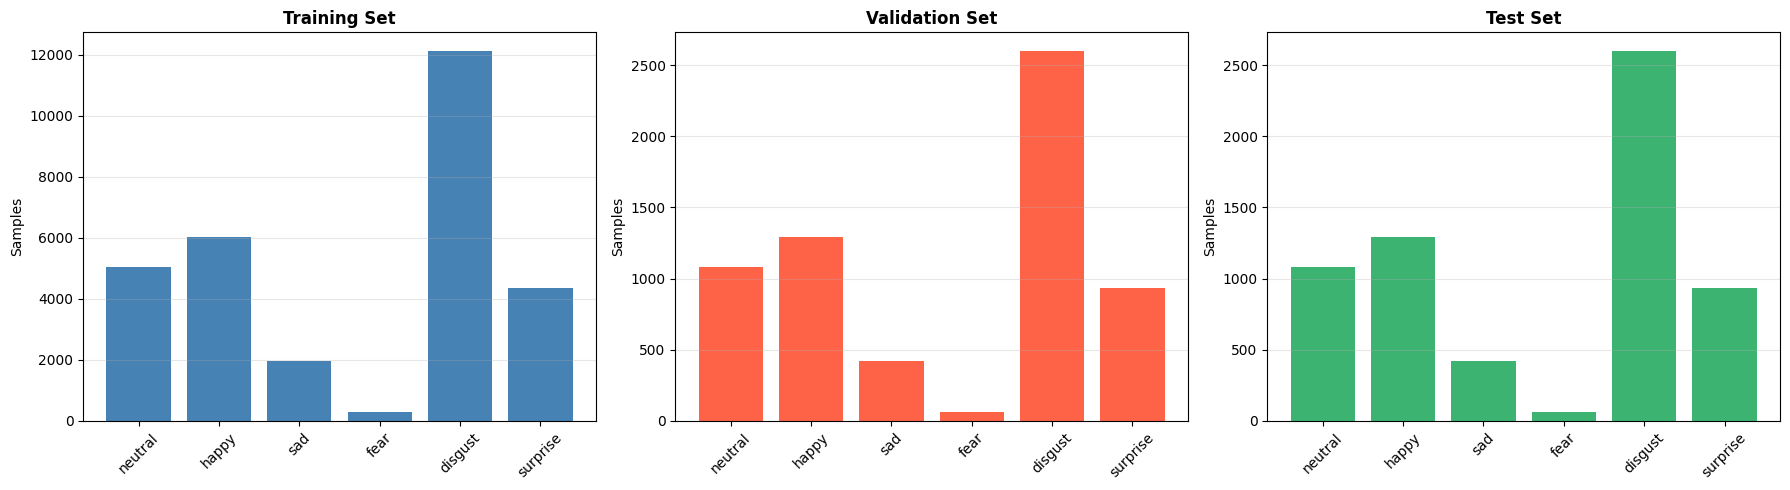

Visualization saved to: /content/drive/MyDrive/NuruAI/processed_data/data_splits.png


In [ ]:
metadata_df = pd.read_csv(os.path.join(Config.OUTPUT_PATH, 'metadata.csv'))

print("STEP 8: DATA SPLITS")
print()
print(f"Total processed samples: {len(metadata_df)}")
print()

# Show how many samples came from images vs video frames
source_counts = metadata_df['source_type'].value_counts()
print("Source breakdown:")
for src, count in source_counts.items():
    print(f"  {src:<10}: {count:>7}")
print()

print("Distribution by emotion:")
print()
print(f"  {'Emotion':<14}  {'Count':>8}")
print(f"  {'-'*14}  {'-'*8}")
for emotion, count in metadata_df['emotion'].value_counts().items():
    print(f"  {emotion:<14}  {count:>8}")
print()

train_data = []
val_data   = []
test_data  = []

print(f"  {'Emotion':<14}  {'Train':>7}  {'Val':>7}  {'Test':>7}")
print(f"  {'-'*14}  {'-'*7}  {'-'*7}  {'-'*7}")

for emotion in Config.EMOTIONS:
    subset = metadata_df[metadata_df['emotion'] == emotion]
    if len(subset) == 0:
        continue

    # First split: separate training from the remaining 30%
    train_part, temp_part = train_test_split(
        subset,
        test_size    = Config.VAL_RATIO + Config.TEST_RATIO,
        random_state = Config.RANDOM_SEED,
    )

    # Second split: divide the remaining 30% equally into val and test
    val_ratio_adj       = Config.VAL_RATIO / (Config.VAL_RATIO + Config.TEST_RATIO)
    val_part, test_part = train_test_split(
        temp_part,
        test_size    = 1 - val_ratio_adj,
        random_state = Config.RANDOM_SEED,
    )

    train_data.append(train_part)
    val_data.append(val_part)
    test_data.append(test_part)

    print(f"  {emotion:<14}  {len(train_part):>7}  {len(val_part):>7}  {len(test_part):>7}")

# Concatenate all emotion splits and shuffle
train_df = pd.concat(train_data, ignore_index=True).sample(frac=1, random_state=Config.RANDOM_SEED).reset_index(drop=True)
val_df   = pd.concat(val_data,   ignore_index=True).sample(frac=1, random_state=Config.RANDOM_SEED).reset_index(drop=True)
test_df  = pd.concat(test_data,  ignore_index=True).sample(frac=1, random_state=Config.RANDOM_SEED).reset_index(drop=True)

total = len(metadata_df)
print()
print("Split summary:")
print()
print(f"  Training set   : {len(train_df):>7}  ({len(train_df)/total*100:.1f}%)")
print(f"  Validation set : {len(val_df):>7}  ({len(val_df)/total*100:.1f}%)")
print(f"  Test set       : {len(test_df):>7}  ({len(test_df)/total*100:.1f}%)")
print(f"  Total          : {total:>7}")
print()

train_df.to_csv(os.path.join(Config.OUTPUT_PATH, 'train_split.csv'), index=False)
val_df.to_csv(  os.path.join(Config.OUTPUT_PATH, 'val_split.csv'),   index=False)
test_df.to_csv( os.path.join(Config.OUTPUT_PATH, 'test_split.csv'),  index=False)

print("Split files saved to output directory.")
print()

# Visualize the emotion distribution across all three splits
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
splits = [
    (train_df, 'Training Set',   'steelblue'),
    (val_df,   'Validation Set', 'tomato'),
    (test_df,  'Test Set',       'mediumseagreen'),
]

for idx, (split_df, title, color) in enumerate(splits):
    counts   = split_df['emotion'].value_counts()
    emotions = [e for e in Config.EMOTIONS if e in counts.index]
    axes[idx].bar(emotions, [counts[e] for e in emotions], color=color)
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Samples')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = os.path.join(Config.OUTPUT_PATH, 'data_splits.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Visualization saved to: {save_path}")



***Step 9: Visualize Simple Images***

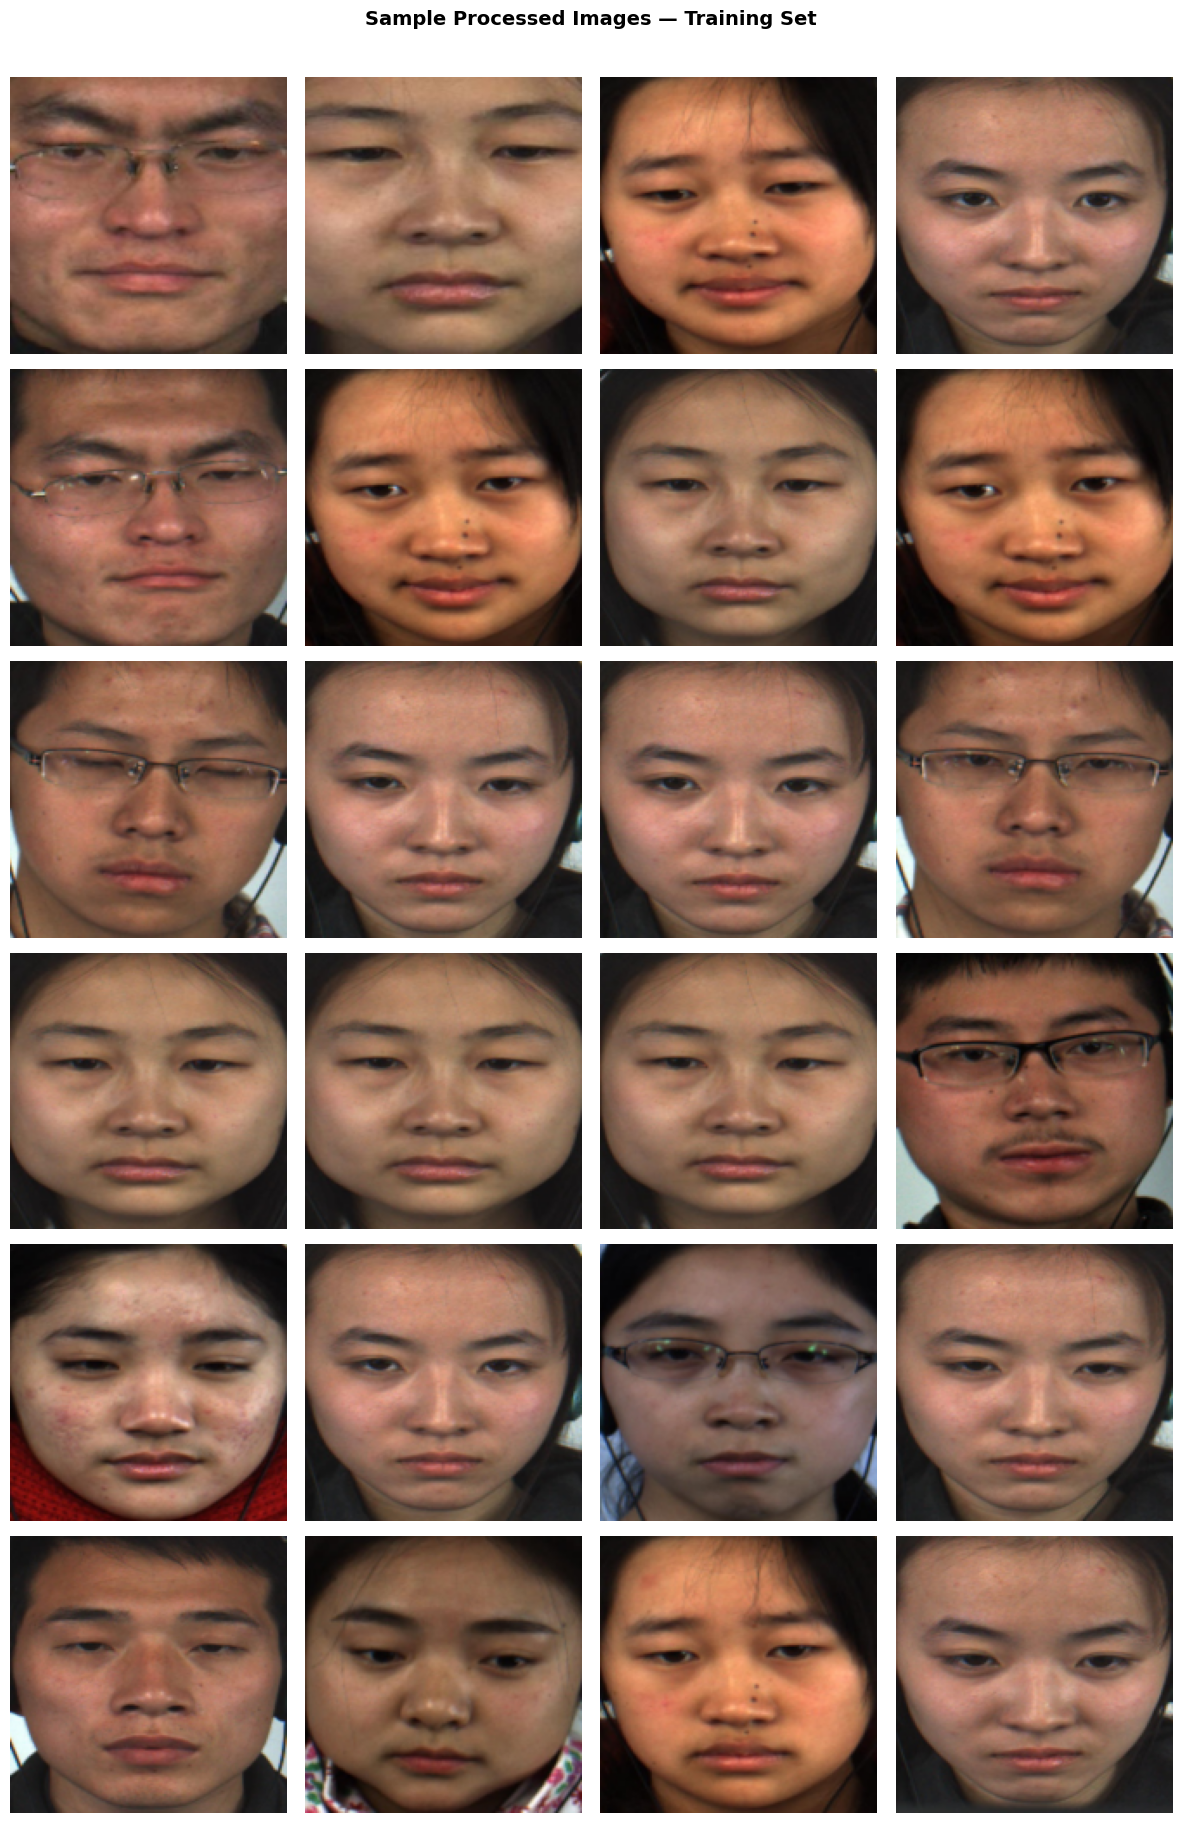

STEP 9: SAMPLE IMAGES

Visualization saved to: /content/drive/MyDrive/NuruAI/processed_data/sample_images.png

Data preparation complete.
Next: Model Architecture and Training.


In [ ]:
train_df = pd.read_csv(os.path.join(Config.OUTPUT_PATH, 'train_split.csv'))
processed_images_dir = os.path.join(Config.OUTPUT_PATH, 'processed_images')
samples_per_emotion  = 4

emotions_present = [e for e in Config.EMOTIONS
                    if len(train_df[train_df['emotion'] == e]) > 0]

fig, axes = plt.subplots(
    len(emotions_present),
    samples_per_emotion,
    figsize=(12, 3 * len(emotions_present))
)

if len(emotions_present) == 1:
    axes = [axes]

for row_idx, emotion in enumerate(emotions_present):
    subset  = train_df[train_df['emotion'] == emotion]
    samples = subset.sample(
        n            = min(samples_per_emotion, len(subset)),
        random_state = Config.RANDOM_SEED
    )

    for col_idx, (_, row) in enumerate(samples.iterrows()):
        if col_idx >= samples_per_emotion:
            break

        img_path = os.path.join(processed_images_dir, row['processed_filename'])
        img      = Image.open(img_path)

        axes[row_idx][col_idx].imshow(img)
        axes[row_idx][col_idx].axis('off')

        if col_idx == 0:
            axes[row_idx][col_idx].set_ylabel(
                emotion.upper(),
                fontsize   = 11,
                fontweight = 'bold',
                rotation   = 0,
                ha         = 'right',
                va         = 'center',
            )

plt.suptitle('Sample Processed Images — Training Set',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = os.path.join(Config.OUTPUT_PATH, 'sample_images.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print("STEP 9: SAMPLE IMAGES")
print()
print(f"Visualization saved to: {save_path}")
print()
print("Data preparation complete.")
print("Next: Model Architecture and Training.")

***Step 10: Dataset Loader***

In [ ]:
import torch.optim as optim
from facenet_pytorch import InceptionResnetV1
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

class EmotionDataset(Dataset):

    def __init__(self, csv_path, images_dir, transform, emotion_to_idx):
        self.df             = pd.read_csv(csv_path)
        self.images_dir     = images_dir
        self.transform      = transform
        self.emotion_to_idx = emotion_to_idx

        valid_mask = self.df['emotion'].isin(emotion_to_idx.keys())
        removed    = len(self.df) - valid_mask.sum()
        self.df    = self.df[valid_mask].reset_index(drop=True)

        if removed > 0:
            print(f"  Removed {removed} rows with unrecognised emotion labels")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['processed_filename'])
        label    = self.emotion_to_idx[row['emotion']]
        img      = Image.open(img_path).convert('RGB')
        img      = self.transform(img)
        return img, label


EMOTIONS = ['neutral', 'happy', 'sad', 'angry', 'fear', 'disgust', 'surprise']

emotion_to_idx = {emotion: idx for idx, emotion in enumerate(EMOTIONS)}
idx_to_emotion = {idx: emotion for emotion, idx in emotion_to_idx.items()}

train_transform = transforms.Compose([
    transforms.Resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_transform = transforms.Compose([
    transforms.Resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

IMAGES_DIR = os.path.join(Config.OUTPUT_PATH, 'processed_images')

train_dataset = EmotionDataset(
    csv_path=os.path.join(Config.OUTPUT_PATH, 'train_split.csv'),
    images_dir=IMAGES_DIR, transform=train_transform, emotion_to_idx=emotion_to_idx)

val_dataset = EmotionDataset(
    csv_path=os.path.join(Config.OUTPUT_PATH, 'val_split.csv'),
    images_dir=IMAGES_DIR, transform=val_transform, emotion_to_idx=emotion_to_idx)

test_dataset = EmotionDataset(
    csv_path=os.path.join(Config.OUTPUT_PATH, 'test_split.csv'),
    images_dir=IMAGES_DIR, transform=val_transform, emotion_to_idx=emotion_to_idx)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE,
                          shuffle=True,  num_workers=Config.NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=Config.BATCH_SIZE,
                          shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=Config.BATCH_SIZE,
                          shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)

train_df     = pd.read_csv(os.path.join(Config.OUTPUT_PATH, 'train_split.csv'))
class_counts = train_df['emotion'].value_counts()
total        = len(train_df)
class_weights = []

print("STEP 10: DATASET AND DATALOADER")
print()
print(f"  Training samples   : {len(train_dataset)}")
print(f"  Validation samples : {len(val_dataset)}")
print(f"  Test samples       : {len(test_dataset)}")
print()
print("  Emotion to index mapping:")
for emotion, idx in emotion_to_idx.items():
    print(f"    {idx} : {emotion}")
print()
print("  Class weights:")
for emotion in EMOTIONS:
    count  = class_counts.get(emotion, 1)
    weight = total / (len(EMOTIONS) * count)
    class_weights.append(weight)
    print(f"    {emotion:<12}: {count:>6} samples   weight = {weight:.4f}")

class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print()
print("Datasets and dataloaders ready.")



STEP 10: DATASET AND DATALOADER

  Training samples   : 29816
  Validation samples : 6389
  Test samples       : 6392

  Emotion to index mapping:
    0 : neutral
    1 : happy
    2 : sad
    3 : angry
    4 : fear
    5 : disgust
    6 : surprise

  Class weights:
    neutral     :   5042 samples   weight = 0.8448
    happy       :   6015 samples   weight = 0.7081
    sad         :   1974 samples   weight = 2.1578
    angry       :      1 samples   weight = 4259.4286
    fear        :    289 samples   weight = 14.7385
    disgust     :  12132 samples   weight = 0.3511
    surprise    :   4364 samples   weight = 0.9760

Datasets and dataloaders ready.


***Step 11: Model Architecture***

In [ ]:
class NuruAI_Model(nn.Module):

    def __init__(self, num_emotions=7, dropout=0.5, freeze_backbone=False):
        super(NuruAI_Model, self).__init__()

        self.face_encoder = InceptionResnetV1(
            pretrained='vggface2', classify=False, num_classes=None)

        if freeze_backbone:
            for param in self.face_encoder.parameters():
                param.requires_grad = False
            print("  Backbone fully frozen — only classifier head will train")
        else:
            frozen = 0
            for name, param in self.face_encoder.named_parameters():
                if 'block8' not in name and 'last' not in name and 'logits' not in name:
                    param.requires_grad = False
                    frozen += 1
            print(f"  Partial fine-tuning: {frozen} early layers frozen")

        self.emotion_classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.6),
            nn.Linear(128, num_emotions),
        )

    def forward(self, x):
        embeddings     = self.face_encoder(x)
        emotion_logits = self.emotion_classifier(embeddings)
        return embeddings, emotion_logits

    def get_embedding(self, x):
        with torch.no_grad():
            return self.face_encoder(x)

    def predict_emotion(self, x):
        with torch.no_grad():
            embeddings, logits = self.forward(x)
            probs           = torch.softmax(logits, dim=1)
            predicted_class = torch.argmax(probs, dim=1)
        return predicted_class, probs


print("STEP 11: MODEL ARCHITECTURE")
print()

model = NuruAI_Model(num_emotions=len(EMOTIONS), dropout=0.5, freeze_backbone=False)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print()
print(f"  Total parameters     : {total_params:>12,}")
print(f"  Trainable parameters : {trainable_params:>12,}")
print(f"  Frozen parameters    : {total_params - trainable_params:>12,}")
print()
print("Model initialized.")


STEP 11: MODEL ARCHITECTURE



  0%|          | 0.00/107M [00:00<?, ?B/s]

  Partial fine-tuning: 361 early layers frozen

  Total parameters     :   28,076,222
  Trainable parameters :    7,112,894
  Frozen parameters    :   20,963,328

Model initialized.


***Step 12: Training Setup***

In [ ]:
from datetime import datetime

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=Config.LEARNING_RATE,
    weight_decay=Config.WEIGHT_DECAY,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=Config.LR_FACTOR, patience=Config.LR_PATIENCE)

print("STEP 12: TRAINING SETUP")
print()
print(f"  Loss        : CrossEntropyLoss with class weights")
print(f"  Optimizer   : AdamW  lr={Config.LEARNING_RATE}  wd={Config.WEIGHT_DECAY}")
print(f"  Scheduler   : ReduceLROnPlateau  patience={Config.LR_PATIENCE}  factor={Config.LR_FACTOR}")
print(f"  Early stop  : patience={Config.PATIENCE} epochs")
print()
print("Training setup complete.")


STEP 12: TRAINING SETUP

  Loss        : CrossEntropyLoss with class weights
  Optimizer   : AdamW  lr=0.001  wd=0.0001
  Scheduler   : ReduceLROnPlateau  patience=5  factor=0.5
  Early stop  : patience=10 epochs

Training setup complete.


***Step 13: Training Loop***

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0

    for images, labels in tqdm(loader, desc="  Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        _, logits = model(images)
        loss      = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (torch.argmax(logits, dim=1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="  Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)
            _, logits = model(images)
            loss      = criterion(logits, labels)
            predicted = torch.argmax(logits, dim=1)
            total_loss += loss.item() * images.size(0)
            correct    += (predicted == labels).sum().item()
            total      += images.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


print("STEP 13: TRAINING LOOP")
print()

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

best_val_loss    = float('inf')
patience_counter = 0
best_model_path  = os.path.join(Config.MODEL_PATH, 'best_model.pth')
training_start   = datetime.now()

print(f"Training started : {training_start.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Max epochs       : {Config.NUM_EPOCHS}")
print(f"Early stopping   : {Config.PATIENCE} epochs patience")
print()

for epoch in range(1, Config.NUM_EPOCHS + 1):
    current_lr = optimizer.param_groups[0]['lr']

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save({
            'epoch'                : epoch,
            'model_state_dict'     : model.state_dict(),
            'optimizer_state_dict' : optimizer.state_dict(),
            'val_loss'             : val_loss,
            'val_acc'              : val_acc,
            'emotion_to_idx'       : emotion_to_idx,
            'idx_to_emotion'       : idx_to_emotion,
            'config'               : {
                'num_emotions' : len(EMOTIONS),
                'image_size'   : Config.IMAGE_SIZE,
                'emotions'     : EMOTIONS,
            },
        }, best_model_path)
        marker = "  saved"
    else:
        patience_counter += 1
        marker            = f"  patience {patience_counter}/{Config.PATIENCE}"

    print(
        f"Epoch {epoch:>3}/{Config.NUM_EPOCHS}  "
        f"train loss {train_loss:.4f}  acc {train_acc:.4f}  "
        f"val loss {val_loss:.4f}  acc {val_acc:.4f}  "
        f"lr {current_lr:.6f}"
        f"{marker}"
    )

    if patience_counter >= Config.PATIENCE:
        print()
        print(f"Early stopping triggered at epoch {epoch}.")
        break

print()
print(f"Training completed in: {datetime.now() - training_start}")



STEP 13: TRAINING LOOP

Training started : 2026-04-05 12:19:22
Max epochs       : 50
Early stopping   : 10 epochs patience



Epoch   1/50  train loss 0.6471  acc 0.7296  val loss 0.3728  acc 0.8330  lr 0.001000  saved


Epoch   2/50  train loss 0.3690  acc 0.8516  val loss 0.1522  acc 0.9325  lr 0.001000  saved


Epoch   3/50  train loss 0.2863  acc 0.8861  val loss 0.0801  acc 0.9718  lr 0.001000  saved


Epoch   4/50  train loss 0.2341  acc 0.9093  val loss 0.1224  acc 0.9588  lr 0.001000  patience 1/10


...

Epoch  46/50  train loss 0.0208  acc 0.9930  val loss 0.0016  acc 0.9998  lr 0.000500  saved


Epoch  47/50  train loss 0.0180  acc 0.9943  val loss 0.0039  acc 0.9984  lr 0.000500  patience 1/10


Epoch  48/50  train loss 0.0201  acc 0.9935  val loss 0.0016  acc 0.9994  lr 0.000500  patience 2/10


Epoch  49/50  train loss 0.0181  acc 0.9940  val loss 0.0036  acc 0.9987  lr 0.000500  patience 3/10


Epoch  50/50  train loss 0.0182  acc 0.9940  val loss 0.0008  acc 0.9995  lr 0.000500  saved

Training completed in: 2:41:11.592677


***Step 14: Training Curves***

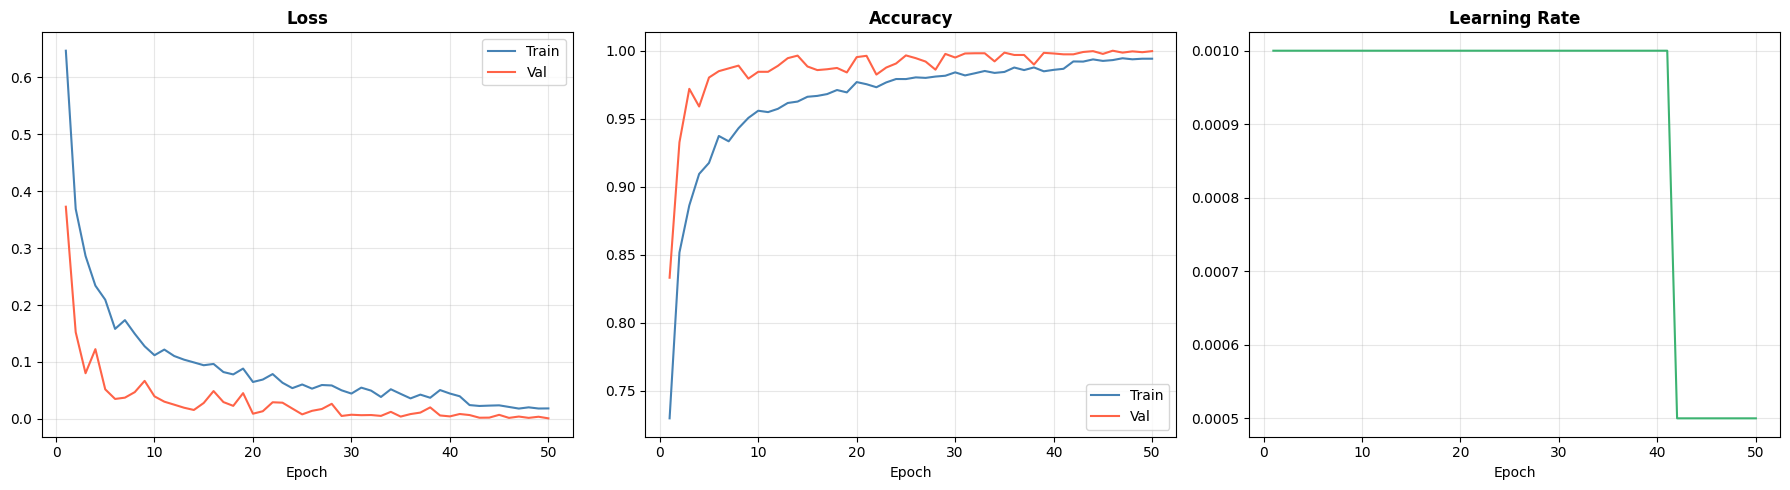

Training curves saved to: /content/drive/MyDrive/NuruAI/models/training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(ep, history['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['train_acc'], label='Train', color='steelblue')
axes[1].plot(ep, history['val_acc'],   label='Val',   color='tomato')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(ep, history['lr'], color='mediumseagreen')
axes[2].set_title('Learning Rate', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)

plt.tight_layout()
curves_path = os.path.join(Config.MODEL_PATH, 'training_curves.png')
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Training curves saved to: {curves_path}")




***Step 15: Evaluation***

STEP 15: EVALUATION

Best model loaded from epoch 50
Best val loss     : 0.0008
Best val accuracy : 0.9995



Test loss     : 0.0014
Test accuracy : 0.9989

Classification report:

              precision    recall  f1-score   support

     neutral     1.0000    1.0000    1.0000      1081
       happy     0.9985    1.0000    0.9992      1290
         sad     0.9906    1.0000    0.9953       423
        fear     1.0000    1.0000    1.0000        62
     disgust     1.0000    0.9981    0.9990      2600
    surprise     0.9989    0.9979    0.9984       936

    accuracy                         0.9989      6392
   macro avg     0.9980    0.9993    0.9987      6392
weighted avg     0.9989    0.9989    0.9989      6392

Note: ['angry'] had no samples in the test set — excluded from report.



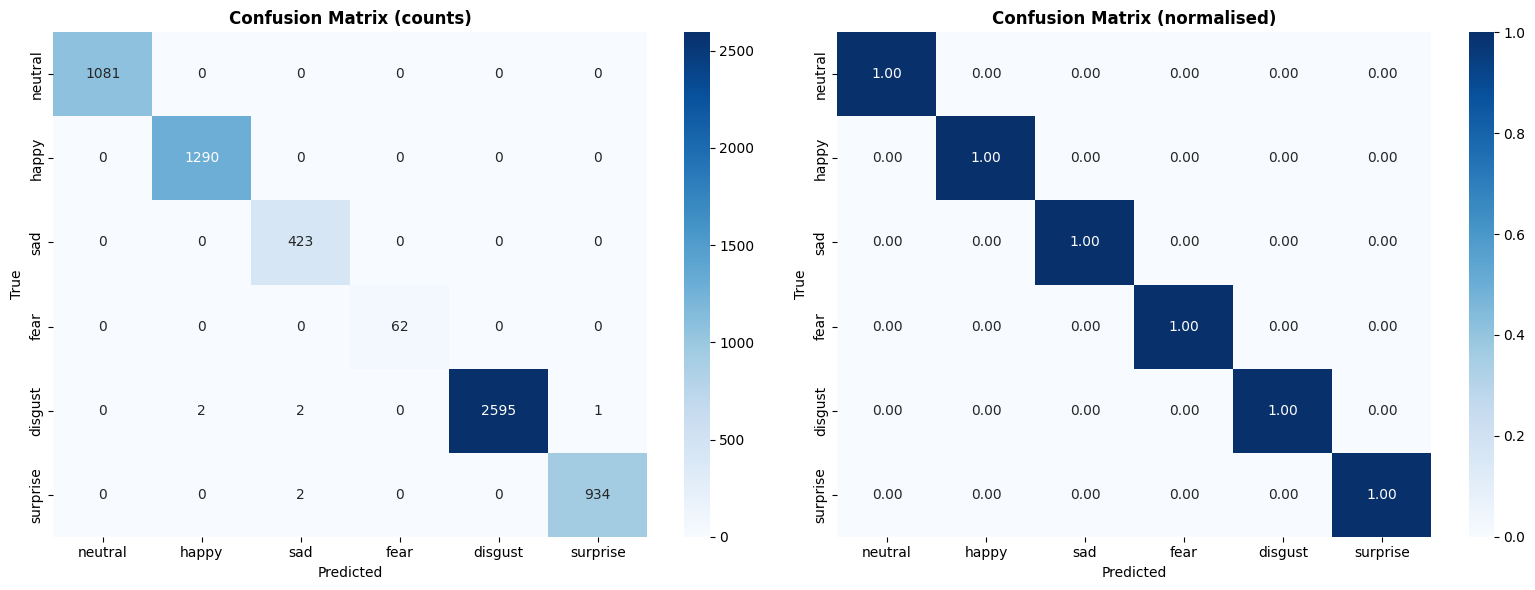

Confusion matrix saved to: /content/drive/MyDrive/NuruAI/models/confusion_matrix.png


In [ ]:
print("STEP 15: EVALUATION")
print()

checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

print(f"Best model loaded from epoch {checkpoint['epoch']}")
print(f"Best val loss     : {checkpoint['val_loss']:.4f}")
print(f"Best val accuracy : {checkpoint['val_acc']:.4f}")
print()

test_loss, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")
print()

# Find which classes actually appear in the test set predictions
# This handles the case where one emotion class has no samples
classes_in_test   = sorted(set(test_labels) | set(test_preds))
target_names_used = [EMOTIONS[i] for i in classes_in_test]

print("Classification report:")
print()
print(classification_report(
    test_labels,
    test_preds,
    labels       = classes_in_test,
    target_names = target_names_used,
    digits       = 4,
))

# Note which emotions were missing from the test set
missing = [EMOTIONS[i] for i in range(len(EMOTIONS)) if i not in classes_in_test]
if missing:
    print(f"Note: {missing} had no samples in the test set — excluded from report.")
    print()

cm     = confusion_matrix(test_labels, test_preds, labels=classes_in_test)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_used, yticklabels=target_names_used,
            ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=target_names_used, yticklabels=target_names_used,
            ax=axes[1])
axes[1].set_title('Confusion Matrix (normalised)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
cm_path = os.path.join(Config.MODEL_PATH, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Confusion matrix saved to: {cm_path}")



***Step 16: Save Model***

In [ ]:
print("STEP 16: SAVING MODEL")
print()

model_info = {
    'model_name'     : 'NuruAI_EmotionModel',
    'architecture'   : 'InceptionResnetV1 + EmotionClassifier',
    'pretrained_on'  : 'VGGFace2',
    'num_emotions'   : len(EMOTIONS),
    'emotions'       : EMOTIONS,
    'emotion_to_idx' : emotion_to_idx,
    'image_size'     : Config.IMAGE_SIZE,
    'embedding_dim'  : 512,
    'test_accuracy'  : round(test_acc, 4),
    'test_loss'      : round(test_loss, 4),
    'best_epoch'     : checkpoint['epoch'],
    'best_val_loss'  : round(checkpoint['val_loss'], 4),
    'best_val_acc'   : round(checkpoint['val_acc'], 4),
    'trained_on'     : ['CASME_A', 'CASME_B', 'CASME_II_Cropped', 'CASME_II_RAW'],
    'total_samples'  : len(train_dataset) + len(val_dataset) + len(test_dataset),
    'training_date'  : training_start.strftime('%Y-%m-%d'),
}

model_info_path = os.path.join(Config.MODEL_PATH, 'model_info.json')
with open(model_info_path, 'w') as f:
    json.dump(model_info, f, indent=2)

print(f"  Model checkpoint : {best_model_path}")
print(f"  Model metadata   : {model_info_path}")
print()
print("Summary:")
print()
print(f"  Test accuracy  : {test_acc:.4f}")
print(f"  Test loss      : {test_loss:.4f}")
print(f"  Best val acc   : {checkpoint['val_acc']:.4f}")
print(f"  Best epoch     : {checkpoint['epoch']}")
print()
print("Model training complete.")
print("Next: Flask API development.")




STEP 16: SAVING MODEL

  Model checkpoint : /content/drive/MyDrive/NuruAI/models/best_model.pth
  Model metadata   : /content/drive/MyDrive/NuruAI/models/model_info.json

Summary:

  Test accuracy  : 0.9989
  Test loss      : 0.0014
  Best val acc   : 0.9995
  Best epoch     : 50

Model training complete.
Next: Flask API development.


***Step 17: Install Flask API Dependencies***

In [ ]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
    print(f'  Installed : {pkg}')

print('STEP 17: INSTALLING FLASK API DEPENDENCIES')
print()
for pkg in ['flask', 'flask-cors', 'pyngrok', 'requests']:
    install(pkg)
print()
print('Installation complete.')


STEP 17: INSTALLING FLASK API DEPENDENCIES

  Installed : flask
  Installed : flask-cors
  Installed : pyngrok
  Installed : requests

Installation complete.


***Load Saved Model for API***

In [ ]:
import base64
from PIL import Image
from io import BytesIO
from facenet_pytorch import InceptionResnetV1


# Model definition (MUST match training architecture exactly)
#
# pretrained=None because we load our own trained weights.
# classify=False so forward() returns the 512-dim embedding directly.
# The emotion_classifier head is identical to training (Cell 34 / Step 11).

class NuruAI_Model(nn.Module):

    def __init__(self, num_emotions=7, dropout=0.5):
        super(NuruAI_Model, self).__init__()

        # Backbone: FaceNet pretrained on VGGFace2, returns 512-dim embedding
        self.face_encoder = InceptionResnetV1(
            pretrained=None, classify=False, num_classes=None)

        # Emotion classifier head — identical to training
        self.emotion_classifier = nn.Sequential(
            nn.Linear(512, 256), nn.BatchNorm1d(256),
            nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.BatchNorm1d(128),
            nn.ReLU(inplace=True), nn.Dropout(dropout * 0.6),
            nn.Linear(128, num_emotions),
        )

    def forward(self, x):
        embeddings     = self.face_encoder(x)      # (B, 512)
        emotion_logits = self.emotion_classifier(embeddings)
        return embeddings, emotion_logits

    def get_embedding(self, x):
        with torch.no_grad():
            return self.face_encoder(x)            # (B, 512)


MODEL_PATH      = '/content/drive/MyDrive/NuruAI/models/best_model.pth'
MODEL_INFO_PATH = '/content/drive/MyDrive/NuruAI/models/model_info.json'
BASELINES_PATH  = '/content/drive/MyDrive/NuruAI/baselines'
USER_DATA_PATH  = '/content/drive/MyDrive/NuruAI/user_data'

os.makedirs(BASELINES_PATH, exist_ok=True)
os.makedirs(USER_DATA_PATH, exist_ok=True)

# Load model info

with open(MODEL_INFO_PATH) as f:
    model_info = json.load(f)

EMOTIONS     = model_info['emotions']
NUM_EMOTIONS = model_info['num_emotions']
IMAGE_SIZE   = model_info['image_size']

print('Step 17: Load Model for API')
print()
print('Model info loaded:')
print(f'  Emotions   : {EMOTIONS}')
print(f'  Image size : {IMAGE_SIZE}')
print(f'  Test acc   : {model_info["test_accuracy"]}')
print()

# Load model weights

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
api_model = NuruAI_Model(num_emotions=NUM_EMOTIONS)
checkpoint = torch.load(MODEL_PATH, map_location=device)

# strict=False is needed because the checkpoint also contains optimizer state
# and other keys — it does NOT cause weight mismatch since architectures match.
api_model.load_state_dict(checkpoint['model_state_dict'], strict=False)
api_model.to(device)
api_model.eval()

print(f'Model loaded from epoch {checkpoint["epoch"]}')
print(f'Device : {device}')
print()

# Initialize MTCNN face detector

mtcnn_api = MTCNN(
    image_size=IMAGE_SIZE, margin=0, min_face_size=40,
    thresholds=[0.6, 0.7, 0.7], post_process=True,
    device=device, keep_all=False,
)

print('Face detector initialized.')
print()
print('Step 17 complete. Model is ready for API use.')



Step 17: Load Model for API

Model info loaded:
  Emotions   : ['neutral', 'happy', 'sad', 'angry', 'fear', 'disgust', 'surprise']
  Image size : 160
  Test acc   : 0.9989

Model loaded from epoch 50
Device : cuda

Face detector initialized.

Step 17 complete. Model is ready for API use.


***Step 18: API Helper Functions***

In [ ]:
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])


def decode_image(b64_string):
    if ',' in b64_string:
        b64_string = b64_string.split(',')[1]
    return Image.open(BytesIO(base64.b64decode(b64_string))).convert('RGB')


def detect_face(pil_img):
    face = mtcnn_api(pil_img)
    if face is None:
        return None
    return face.unsqueeze(0).to(device)


def classify_emotion(face_tensor):
    with torch.no_grad():
        _, logits = api_model(face_tensor)
        probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    idx    = int(np.argmax(probs))
    label  = EMOTIONS[idx]
    conf   = float(probs[idx])
    all_p  = {EMOTIONS[i]: float(probs[i]) for i in range(len(EMOTIONS))}
    return label, conf, all_p


def get_embedding(face_tensor):
    with torch.no_grad():
        return api_model.get_embedding(face_tensor).squeeze().cpu().numpy()


def cosine_sim(e1, e2):
    e1 = e1 / (np.linalg.norm(e1) + 1e-8)
    e2 = e2 / (np.linalg.norm(e2) + 1e-8)
    return float(np.dot(e1, e2))


def save_baseline(user_id, embeddings):
    avg = np.mean(embeddings, axis=0).tolist()
    data = {'user_id': user_id, 'embedding': avg,
            'created_at': datetime.now().isoformat(),
            'num_samples': len(embeddings)}
    with open(os.path.join(BASELINES_PATH, f'{user_id}.json'), 'w') as f:
        json.dump(data, f)
    return avg


def load_baseline(user_id):
    path = os.path.join(BASELINES_PATH, f'{user_id}.json')
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return np.array(json.load(f)['embedding'])


def log_event(user_id, event_type, data):
    path  = os.path.join(USER_DATA_PATH, f'{user_id}_events.jsonl')
    event = {'event_type': event_type,
             'timestamp': datetime.now().isoformat(),
             'user_id': user_id, **data}
    with open(path, 'a') as f:
        f.write(json.dumps(event) + '\n')


def get_history(user_id, limit=50):
    path = os.path.join(USER_DATA_PATH, f'{user_id}_events.jsonl')
    if not os.path.exists(path):
        return []
    events = []
    with open(path) as f:
        for line in f:
            try:
                e = json.loads(line.strip())
                if e.get('event_type') == 'emotion_detection':
                    events.append(e)
            except Exception:
                continue
    return events[-limit:]


# Warm, welcoming messages shown to the user after facial login.
# Each message acknowledges the detected emotion, asks what the user needs,
# and offers a specific coping tool — matching the NuruAI brand voice.
EMOTION_SUPPORT = {
    'happy': {
        'tool': 'journal',
        'message': "You look like you're in a good place today. "
                   "This is a great time to capture how you're feeling in your journal.",
    },
    'neutral': {
        'tool': 'breathing',
        'message': "You seem calm and steady today. "
                   "A quick breathing exercise can help you stay centred throughout the day.",
    },
    'sad': {
        'tool': 'music',
        'message': "I noticed you might be feeling a little sad right now. "
                   "That's okay — you're not alone. "
                   "Would you like to talk about it, or would some calming music help?",
    },
    'fear': {
        'tool': 'breathing',
        'message': "You seem a little anxious or worried. "
                   "You're safe here. "
                   "A breathing exercise can help calm your nervous system — want to try one?",
    },
    'disgust': {
        'tool': 'journal',
        'message': "Something seems to be bothering you right now. "
                   "Writing about it in your journal can help you process what's going on.",
    },
    'surprise': {
        'tool': 'calmme',
        'message': "You seem a little startled or overwhelmed. "
                   "Take a breath — the CalmMe screen has tools that can help you settle.",
    },
    'angry': {
        'tool': 'anger',
        'message': "I can see you might be feeling frustrated or upset. "
                   "That's completely valid. "
                   "The anger management tools are here to help you work through it.",
    },
}


print('STEP 18: API HELPER FUNCTIONS')
print()
print('All helper functions defined.')


STEP 18: API HELPER FUNCTIONS

All helper functions defined.


***Step 19: Flask API Endpoints***

In [ ]:
from flask import Flask, request, jsonify
from flask_cors import CORS

app = Flask(__name__)
CORS(app)


@app.route('/setup_baseline', methods=['POST'])
def setup_baseline():
    try:
        data    = request.get_json()
        user_id = data.get('user_id')
        images  = data.get('images', [])
        if not user_id or not images:
            return jsonify({'success': False, 'message': 'user_id and images required'}), 400
        embeddings = []
        for img_b64 in images:
            try:
                face = detect_face(decode_image(img_b64))
                if face is not None:
                    embeddings.append(get_embedding(face))
            except Exception:
                continue
        if len(embeddings) < 3:
            return jsonify({'success': False,
                'message': f'Only {len(embeddings)} faces detected. Need at least 3.'}), 400
        save_baseline(user_id, embeddings)
        return jsonify({'success': True, 'message': 'Baseline created.',
                        'num_samples': len(embeddings)})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/login', methods=['POST'])
def login():
    try:
        data    = request.get_json()
        user_id = data.get('user_id')
        img_b64 = data.get('image')
        if not user_id or not img_b64:
            return jsonify({'success': False, 'message': 'user_id and image required'}), 400
        baseline = load_baseline(user_id)
        if baseline is None:
            return jsonify({'success': False,
                'message': 'No baseline found. Please complete facial setup first.'}), 404
        face = detect_face(decode_image(img_b64))
        if face is None:
            return jsonify({'success': False, 'authenticated': False,
                'message': 'No face detected. Look directly at the camera.'}), 400
        emb           = get_embedding(face)
        similarity    = cosine_sim(emb, baseline)
        authenticated = similarity >= 0.70
        emotion, conf, all_p = classify_emotion(face)
        support = EMOTION_SUPPORT.get(emotion, EMOTION_SUPPORT['neutral'])
        log_event(user_id, 'emotion_detection',
                  {'emotion': emotion, 'confidence': conf, 'trigger': 'login'})
        return jsonify({
            'success'      : True,
            'authenticated': authenticated,
            'similarity'   : round(similarity, 4),
            'emotion'      : emotion,
            'confidence'   : round(conf, 4),
            'all_emotions' : {k: round(v, 4) for k, v in all_p.items()},
            'support'      : support,
            'message'      : 'Login successful.' if authenticated else 'Face not recognised.',
        })
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/detect_emotion', methods=['POST'])
def detect_emotion():
    try:
        data    = request.get_json()
        user_id = data.get('user_id', 'unknown')
        img_b64 = data.get('image')
        trigger = data.get('trigger', 'manual')
        if not img_b64:
            return jsonify({'success': False, 'message': 'image required'}), 400
        face = detect_face(decode_image(img_b64))
        if face is None:
            return jsonify({'success': False, 'message': 'No face detected.'}), 400
        emotion, conf, all_p = classify_emotion(face)
        support = EMOTION_SUPPORT.get(emotion, EMOTION_SUPPORT['neutral'])
        log_event(user_id, 'emotion_detection',
                  {'emotion': emotion, 'confidence': conf, 'trigger': trigger})
        return jsonify({'success': True, 'emotion': emotion,
                        'confidence': round(conf, 4),
                        'all_emotions': {k: round(v, 4) for k, v in all_p.items()},
                        'support': support})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/log_mood', methods=['POST'])
def log_mood():
    try:
        data    = request.get_json()
        user_id = data.get('user_id')
        mood    = data.get('mood')
        if not user_id or not mood:
            return jsonify({'success': False, 'message': 'user_id and mood required'}), 400
        log_event(user_id, 'mood_log',
                  {'mood': mood, 'source': 'user_selected',
                   'flutter_timestamp': data.get('timestamp')})
        return jsonify({'success': True, 'message': 'Mood logged.'})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/log_journal', methods=['POST'])
def log_journal():
    try:
        data    = request.get_json()
        user_id = data.get('user_id')
        if not user_id:
            return jsonify({'success': False, 'message': 'user_id required'}), 400
        log_event(user_id, 'journal_entry',
                  {'mood': data.get('mood'), 'word_count': data.get('word_count', 0),
                   'title': data.get('title'),
                   'flutter_timestamp': data.get('timestamp')})
        return jsonify({'success': True, 'message': 'Journal entry logged.'})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/log_chat', methods=['POST'])
def log_chat():
    try:
        data    = request.get_json()
        user_id = data.get('user_id')
        if not user_id:
            return jsonify({'success': False, 'message': 'user_id required'}), 400
        log_event(user_id, 'chat_session',
                  {'message_count': data.get('message_count', 0),
                   'topic': data.get('topic'),
                   'duration_secs': data.get('duration_secs', 0)})
        return jsonify({'success': True, 'message': 'Chat session logged.'})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/emotion_history', methods=['GET'])
def emotion_history():
    try:
        user_id = request.args.get('user_id')
        limit   = int(request.args.get('limit', 50))
        if not user_id:
            return jsonify({'success': False, 'message': 'user_id required'}), 400
        history = get_history(user_id, limit=limit)
        return jsonify({'success': True, 'user_id': user_id,
                        'count': len(history), 'history': history})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500




@app.route('/log_breathing', methods=['POST'])
def log_breathing():
    try:
        data    = request.get_json()
        user_id = data.get('user_id')
        if not user_id:
            return jsonify({'success': False, 'message': 'user_id required'}), 400
        log_event(user_id, 'breathing_session', {
            'technique_name'  : data.get('technique_name', ''),
            'cycles_completed': data.get('cycles_completed', 0),
            'duration_secs'   : data.get('duration_secs', 0),
        })
        return jsonify({'success': True, 'message': 'Breathing session logged.'})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/log_calming', methods=['POST'])
def log_calming():
    try:
        data    = request.get_json()
        user_id = data.get('user_id')
        if not user_id:
            return jsonify({'success': False, 'message': 'user_id required'}), 400
        log_event(user_id, 'calming_session', {
            'activity'     : data.get('activity', ''),
            'duration_secs': data.get('duration_secs', 0),
        })
        return jsonify({'success': True, 'message': 'CalmMe session logged.'})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/daily_report', methods=['GET'])
def daily_report():
    """
    Generates a daily wellbeing report from today's logged events.
    Called by the Flutter analytics screen to get ML-powered daily insights.
    Returns a written summary + wellbeing score + recommended tool.
    """
    try:
        user_id = request.args.get('user_id')
        if not user_id:
            return jsonify({'success': False, 'message': 'user_id required'}), 400

        path = os.path.join(USER_DATA_PATH, f'{user_id}_events.jsonl')
        if not os.path.exists(path):
            return jsonify({'success': True, 'has_data': False,
                'summary': 'No activity recorded yet today.',
                'wellbeing_score': None, 'recommended_tool': 'breathing'})

        today = datetime.now().date().isoformat()
        today_events = []
        with open(path) as f:
            for line in f:
                try:
                    e = json.loads(line.strip())
                    if e.get('timestamp', '').startswith(today):
                        today_events.append(e)
                except Exception:
                    continue

        # Count today's activity
        emotions    = [e for e in today_events if e['event_type'] == 'emotion_detection']
        moods       = [e for e in today_events if e['event_type'] == 'mood_log']
        journals    = [e for e in today_events if e['event_type'] == 'journal_entry']
        chats       = [e for e in today_events if e['event_type'] == 'chat_session']
        breaths     = [e for e in today_events if e['event_type'] == 'breathing_session']
        calming     = [e for e in today_events if e['event_type'] == 'calming_session']

        if not today_events:
            return jsonify({'success': True, 'has_data': False,
                'summary': 'No activity recorded yet today. Open any tool and your daily summary will appear here.',
                'wellbeing_score': None, 'recommended_tool': 'breathing'})

        # Compute simple wellbeing score from detected emotions (0-10)
        emotion_scores = {'happy': 9, 'neutral': 6, 'surprise': 5,
                          'sad': 3, 'fear': 2, 'disgust': 2, 'angry': 2}
        all_detected = [e.get('emotion') for e in emotions if e.get('emotion')]
        wellbeing_score = None
        if all_detected:
            scores = [emotion_scores.get(em, 5) for em in all_detected]
            wellbeing_score = round(sum(scores) / len(scores), 1)

        # Dominant emotion today
        dominant_emotion = None
        if all_detected:
            dominant_emotion = max(set(all_detected), key=all_detected.count)

        # Build written summary
        parts = []
        if dominant_emotion:
            support = EMOTION_SUPPORT.get(dominant_emotion, EMOTION_SUPPORT['neutral'])
            parts.append(support['message'])

        activity_parts = []
        if journals:
            n = len(journals)
            activity_parts.append(f"wrote {'a journal entry' if n == 1 else str(n) + ' journal entries'}")
        if breaths:
            n = len(breaths)
            activity_parts.append(f"completed {'a breathing session' if n == 1 else str(n) + ' breathing sessions'}")
        if chats:
            n = len(chats)
            activity_parts.append(f"had {'a conversation' if n == 1 else str(n) + ' conversations'} with NuruAI")
        if calming:
            n = len(calming)
            activity_parts.append(f"used CalmMe {'once' if n == 1 else str(n) + ' times'}")

        if activity_parts:
            last = activity_parts.pop()
            joined = (', '.join(activity_parts) + ' and ' + last) if activity_parts else last
            parts.append(f"Today you {joined}.")

        # Recommended tool based on latest detected emotion or mood
        recommended_tool = 'breathing'
        if dominant_emotion and dominant_emotion in EMOTION_SUPPORT:
            recommended_tool = EMOTION_SUPPORT[dominant_emotion]['tool']

        summary = ' '.join(parts) if parts else 'You are making progress. Keep going.'

        return jsonify({
            'success'         : True,
            'has_data'        : True,
            'date'            : today,
            'wellbeing_score' : wellbeing_score,
            'dominant_emotion': dominant_emotion,
            'summary'         : summary,
            'recommended_tool': recommended_tool,
            'activity_counts' : {
                'emotions': len(emotions),
                'journals': len(journals),
                'breaths' : len(breaths),
                'chats'   : len(chats),
                'calming' : len(calming),
            },
            'is_ml_generated' : True,
        })
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/weekly_report', methods=['GET'])
def weekly_report():
    """
    Generates a weekly wellbeing report from the last 7 days of events.
    Called by the Flutter analytics screen every time it loads.
    """
    try:
        user_id = request.args.get('user_id')
        if not user_id:
            return jsonify({'success': False, 'message': 'user_id required'}), 400

        path = os.path.join(USER_DATA_PATH, f'{user_id}_events.jsonl')
        if not os.path.exists(path):
            return jsonify({'success': True, 'has_data': False,
                'summary': 'No activity yet this week.'})

        from datetime import timedelta
        today    = datetime.now().date()
        week_ago = today - timedelta(days=7)

        week_events = []
        with open(path) as f:
            for line in f:
                try:
                    e = json.loads(line.strip())
                    ts = e.get('timestamp', '')
                    if ts:
                        event_date = datetime.fromisoformat(ts).date()
                        if week_ago <= event_date <= today:
                            week_events.append(e)
                except Exception:
                    continue

        if not week_events:
            return jsonify({'success': True, 'has_data': False,
                'summary': 'No activity recorded this week yet.'})

        emotions = [e for e in week_events if e['event_type'] == 'emotion_detection']
        journals = [e for e in week_events if e['event_type'] == 'journal_entry']
        chats    = [e for e in week_events if e['event_type'] == 'chat_session']
        breaths  = [e for e in week_events if e['event_type'] == 'breathing_session']
        calming  = [e for e in week_events if e['event_type'] == 'calming_session']

        # Average wellbeing from detected emotions
        emotion_scores = {'happy': 9, 'neutral': 6, 'surprise': 5,
                          'sad': 3, 'fear': 2, 'disgust': 2, 'angry': 2}
        all_emotions = [e.get('emotion') for e in emotions if e.get('emotion')]
        avg_wellbeing = None
        if all_emotions:
            scores = [emotion_scores.get(em, 5) for em in all_emotions]
            avg_wellbeing = round(sum(scores) / len(scores), 1)

        # Emotion trend (early week vs late week)
        early = [e for e in emotions if
                 datetime.fromisoformat(e['timestamp']).date() <= week_ago + __import__('datetime').timedelta(days=3)]
        late  = [e for e in emotions if
                 datetime.fromisoformat(e['timestamp']).date() > week_ago + __import__('datetime').timedelta(days=3)]

        trend = None
        if early and late:
            early_avg = sum(emotion_scores.get(e.get('emotion','neutral'),5) for e in early) / len(early)
            late_avg  = sum(emotion_scores.get(e.get('emotion','neutral'),5) for e in late)  / len(late)
            trend = round(late_avg - early_avg, 2)

        # Written summary
        parts = []
        total = len(journals) + len(breaths) + len(chats) + len(calming)

        if avg_wellbeing:
            if avg_wellbeing >= 7:
                parts.append("This has been a strong week for your wellbeing.")
            elif avg_wellbeing >= 5:
                parts.append("Overall this was a steady week with some good moments along the way.")
            else:
                parts.append("It has been a tough week, but the fact that you kept using NuruAI matters.")

        tool_parts = []
        if journals: tool_parts.append(f"{'1 journal entry' if len(journals)==1 else str(len(journals))+' journal entries'}")
        if breaths:  tool_parts.append(f"{'1 breathing session' if len(breaths)==1 else str(len(breaths))+' breathing sessions'}")
        if chats:    tool_parts.append(f"{'1 NuruAI conversation' if len(chats)==1 else str(len(chats))+' NuruAI conversations'}")
        if calming:  tool_parts.append(f"CalmMe used {'once' if len(calming)==1 else str(len(calming))+' times'}")

        if tool_parts:
            parts.append(f"This week: {', '.join(tool_parts)}.")

        if trend is not None:
            if trend > 0.5:
                parts.append("Your mood improved as the week went on — a really positive sign.")
            elif trend < -0.5:
                parts.append("Your mood dipped toward the end of the week. Extra self-care this weekend could help.")

        if total >= 10:
            parts.append("You had a genuinely active week on NuruAI. That level of engagement with your own wellbeing is remarkable.")
        elif total >= 5:
            parts.append("A solid week. Every action you took was a step toward understanding yourself better.")
        elif total > 0:
            parts.append("Even small steps count. Next week, try to add one more activity.")

        return jsonify({
            'success'         : True,
            'has_data'        : True,
            'avg_wellbeing'   : avg_wellbeing,
            'wellbeing_trend' : trend,
            'summary'         : ' '.join(parts),
            'activity_counts' : {
                'journals': len(journals),
                'breaths' : len(breaths),
                'chats'   : len(chats),
                'calming' : len(calming),
            },
            'is_ml_generated' : True,
        })
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500

@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok', 'model': 'NuruAI_EmotionModel',
                    'emotions': EMOTIONS, 'device': str(device)})


print('STEP 19: FLASK API ENDPOINTS')
print()
print('Endpoints registered:')
print('  POST /setup_baseline')
print('  POST /login')
print('  POST /detect_emotion')
print('  POST /log_mood')
print('  POST /log_journal')
print('  POST /log_chat')
print('  GET  /emotion_history')
print('  POST /log_breathing')
print('  POST /log_calming')
print('  GET  /daily_report')
print('  GET  /weekly_report')
print('  GET  /health')
print()
print('Run Step 21 to start the server.')



STEP 19: FLASK API ENDPOINTS

Endpoints registered:
  POST /setup_baseline
  POST /login
  POST /detect_emotion
  POST /log_mood
  POST /log_journal
  POST /log_chat
  GET  /emotion_history
  POST /log_breathing
  POST /log_calming
  GET  /daily_report
  GET  /weekly_report
  GET  /health

Run Step 21 to start the server.


***Step 20: Export Flask App for Railway Deployment***

In [ ]:
import shutil, textwrap



DEPLOY_PATH = '/content/drive/MyDrive/NuruAI/railway_deploy'
os.makedirs(DEPLOY_PATH, exist_ok=True)


# ── app.py ────────────────────────────────────────────────────────────────────

APP_PY = '''"""
NuruAI Flask API — Production (Railway)
"""

import os
import json
import base64
import logging
from io import BytesIO
from datetime import datetime, timedelta

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from flask import Flask, request, jsonify
from flask_cors import CORS

# Optional — only needed if model is hosted remotely
# import requests

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

app = Flask(__name__)
CORS(app)


# ── Configuration ─────────────────────────────────────────────────────────────

MODEL_PATH     = os.environ.get('MODEL_PATH',     'best_model.pth')
MODEL_INFO_PATH = os.environ.get('MODEL_INFO_PATH', 'model_info.json')
BASELINES_PATH = os.environ.get('BASELINES_PATH', 'baselines')
USER_DATA_PATH = os.environ.get('USER_DATA_PATH', 'user_data')
PORT           = int(os.environ.get('PORT', 5000))

os.makedirs(BASELINES_PATH, exist_ok=True)
os.makedirs(USER_DATA_PATH, exist_ok=True)


# ── Model definition (must match training architecture exactly) ───────────────

try:
    from facenet_pytorch import InceptionResnetV1, MTCNN
    FACENET_AVAILABLE = True
except ImportError:
    FACENET_AVAILABLE = False
    logger.warning("facenet-pytorch not available — running in stub mode")


class NuruAI_Model(nn.Module):

    def __init__(self, num_emotions=7, dropout=0.5):
        super().__init__()
        self.face_encoder = InceptionResnetV1(
            pretrained=None, classify=False, num_classes=None)
        self.emotion_classifier = nn.Sequential(
            nn.Linear(512, 256), nn.BatchNorm1d(256),
            nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.BatchNorm1d(128),
            nn.ReLU(inplace=True), nn.Dropout(dropout * 0.6),
            nn.Linear(128, num_emotions),
        )

    def forward(self, x):
        emb    = self.face_encoder(x)
        logits = self.emotion_classifier(emb)
        return emb, logits

    def get_embedding(self, x):
        with torch.no_grad():
            return self.face_encoder(x)


# ── Load model on startup ─────────────────────────────────────────────────────

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
api_model  = None
mtcnn_api  = None
EMOTIONS   = ['neutral', 'happy', 'sad', 'angry', 'fear', 'disgust', 'surprise']
IMAGE_SIZE = 160

def load_model():
    global api_model, mtcnn_api, EMOTIONS, IMAGE_SIZE

    if not FACENET_AVAILABLE:
        logger.warning("Skipping model load — facenet not installed")
        return

    try:
        with open(MODEL_INFO_PATH) as f:
            info = json.load(f)
        EMOTIONS   = info['emotions']
        IMAGE_SIZE = info['image_size']

        api_model = NuruAI_Model(num_emotions=len(EMOTIONS))
        ckpt = torch.load(MODEL_PATH, map_location=device)
        api_model.load_state_dict(ckpt['model_state_dict'], strict=False)
        api_model.to(device)
        api_model.eval()

        mtcnn_api = MTCNN(
            image_size=IMAGE_SIZE, margin=0, min_face_size=40,
            thresholds=[0.6, 0.7, 0.7], post_process=True,
            device=device, keep_all=False,
        )
        logger.info(f"Model loaded. Emotions: {EMOTIONS}. Device: {device}")
    except Exception as e:
        logger.error(f"Model load failed: {e}")

load_model()


# ── Helper functions ──────────────────────────────────────────────────────────

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


def decode_image(b64):
    if ',' in b64:
        b64 = b64.split(',')[1]
    return Image.open(BytesIO(base64.b64decode(b64))).convert('RGB')


def detect_face(pil_img):
    if mtcnn_api is None:
        return None
    face = mtcnn_api(pil_img)
    return face.unsqueeze(0).to(device) if face is not None else None


def classify_emotion(face_tensor):
    with torch.no_grad():
        _, logits = api_model(face_tensor)
        probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    idx   = int(np.argmax(probs))
    return EMOTIONS[idx], float(probs[idx]), {EMOTIONS[i]: float(probs[i]) for i in range(len(EMOTIONS))}


def get_embedding(face_tensor):
    with torch.no_grad():
        return api_model.get_embedding(face_tensor).squeeze().cpu().numpy()


def cosine_sim(e1, e2):
    e1 = e1 / (np.linalg.norm(e1) + 1e-8)
    e2 = e2 / (np.linalg.norm(e2) + 1e-8)
    return float(np.dot(e1, e2))


def save_baseline(user_id, embeddings):
    avg = np.mean(embeddings, axis=0).tolist()
    with open(os.path.join(BASELINES_PATH, f'{user_id}.json'), 'w') as f:
        json.dump({'user_id': user_id, 'embedding': avg,
                   'created_at': datetime.now().isoformat(),
                   'num_samples': len(embeddings)}, f)
    return avg


def load_baseline(user_id):
    path = os.path.join(BASELINES_PATH, f'{user_id}.json')
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return np.array(json.load(f)['embedding'])


def log_event(user_id, event_type, data):
    path  = os.path.join(USER_DATA_PATH, f'{user_id}_events.jsonl')
    event = {'event_type': event_type,
             'timestamp': datetime.now().isoformat(),
             'user_id': user_id, **data}
    with open(path, 'a') as f:
        f.write(json.dumps(event) + '\n')


def get_events(user_id, event_type=None, since_date=None, limit=200):
    path = os.path.join(USER_DATA_PATH, f'{user_id}_events.jsonl')
    if not os.path.exists(path):
        return []
    events = []
    with open(path) as f:
        for line in f:
            try:
                e = json.loads(line.strip())
                if event_type and e.get('event_type') != event_type:
                    continue
                if since_date:
                    ts = e.get('timestamp', '')
                    if ts and datetime.fromisoformat(ts).date() < since_date:
                        continue
                events.append(e)
            except Exception:
                continue
    return events[-limit:]


EMOTION_SUPPORT = {
    'happy': {
        'tool': 'journal',
        'message': "You look like you're in a good place today. "
                   "This is a great time to capture how you're feeling in your journal.",
    },
    'neutral': {
        'tool': 'breathing',
        'message': "You seem calm and steady today. "
                   "A quick breathing exercise can help you stay centred throughout the day.",
    },
    'sad': {
        'tool': 'music',
        'message': "I noticed you might be feeling a little sad right now. "
                   "That's okay — you're not alone. "
                   "Would you like to talk about it, or would some calming music help?",
    },
    'fear': {
        'tool': 'breathing',
        'message': "You seem a little anxious or worried. "
                   "You're safe here. "
                   "A breathing exercise can help calm your nervous system — want to try one?",
    },
    'disgust': {
        'tool': 'journal',
        'message': "Something seems to be bothering you right now. "
                   "Writing about it in your journal can help you process what's going on.",
    },
    'surprise': {
        'tool': 'calmme',
        'message': "You seem a little startled or overwhelmed. "
                   "Take a breath — the CalmMe screen has tools that can help you settle.",
    },
    'angry': {
        'tool': 'anger',
        'message': "I can see you might be feeling frustrated or upset. "
                   "That's completely valid. "
                   "The anger management tools are here to help you work through it.",
    },
}

EMOTION_SCORES = {
    'happy': 9, 'neutral': 6, 'surprise': 5,
    'sad': 3, 'fear': 2, 'disgust': 2, 'angry': 2,
}


# ── API Endpoints ─────────────────────────────────────────────────────────────

@app.route('/setup_baseline', methods=['POST'])
def setup_baseline():
    try:
        data    = request.get_json()
        user_id = data.get('user_id')
        images  = data.get('images', [])
        if not user_id or not images:
            return jsonify({'success': False, 'message': 'user_id and images required'}), 400
        embeddings = []
        for img_b64 in images:
            try:
                face = detect_face(decode_image(img_b64))
                if face is not None:
                    embeddings.append(get_embedding(face))
            except Exception:
                continue
        if len(embeddings) < 3:
            return jsonify({'success': False,
                'message': f'Only {len(embeddings)} faces detected. Need at least 3.'}), 400
        save_baseline(user_id, embeddings)
        return jsonify({'success': True, 'message': 'Baseline created.',
                        'num_samples': len(embeddings)})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/login', methods=['POST'])
def login():
    try:
        data    = request.get_json()
        user_id = data.get('user_id')
        img_b64 = data.get('image')
        if not user_id or not img_b64:
            return jsonify({'success': False, 'message': 'user_id and image required'}), 400
        baseline = load_baseline(user_id)
        if baseline is None:
            return jsonify({'success': False,
                'message': 'No baseline found. Please complete facial setup first.'}), 404
        face = detect_face(decode_image(img_b64))
        if face is None:
            return jsonify({'success': False, 'authenticated': False,
                'message': 'No face detected. Look directly at the camera.'}), 400
        emb           = get_embedding(face)
        similarity    = cosine_sim(emb, baseline)
        authenticated = similarity >= 0.70
        emotion, conf, all_p = classify_emotion(face)
        support = EMOTION_SUPPORT.get(emotion, EMOTION_SUPPORT['neutral'])
        log_event(user_id, 'emotion_detection',
                  {'emotion': emotion, 'confidence': conf, 'trigger': 'login'})
        return jsonify({
            'success'      : True,
            'authenticated': authenticated,
            'similarity'   : round(similarity, 4),
            'emotion'      : emotion,
            'confidence'   : round(conf, 4),
            'all_emotions' : {k: round(v, 4) for k, v in all_p.items()},
            'support'      : support,
            'message'      : 'Login successful.' if authenticated else 'Face not recognised.',
        })
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/detect_emotion', methods=['POST'])
def detect_emotion():
    try:
        data    = request.get_json()
        user_id = data.get('user_id', 'unknown')
        img_b64 = data.get('image')
        trigger = data.get('trigger', 'manual')
        if not img_b64:
            return jsonify({'success': False, 'message': 'image required'}), 400
        face = detect_face(decode_image(img_b64))
        if face is None:
            return jsonify({'success': False, 'message': 'No face detected.'}), 400
        emotion, conf, all_p = classify_emotion(face)
        support = EMOTION_SUPPORT.get(emotion, EMOTION_SUPPORT['neutral'])
        log_event(user_id, 'emotion_detection',
                  {'emotion': emotion, 'confidence': conf, 'trigger': trigger})
        return jsonify({'success': True, 'emotion': emotion,
                        'confidence': round(conf, 4),
                        'all_emotions': {k: round(v, 4) for k, v in all_p.items()},
                        'support': support})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/log_mood', methods=['POST'])
def log_mood():
    try:
        data = request.get_json()
        user_id = data.get('user_id')
        if not user_id:
            return jsonify({'success': False, 'message': 'user_id required'}), 400
        log_event(user_id, 'mood_log', {
            'mood': data.get('mood'),
            'source': 'user_selected',
            'flutter_timestamp': data.get('timestamp'),
        })
        return jsonify({'success': True, 'message': 'Mood logged.'})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/log_journal', methods=['POST'])
def log_journal():
    try:
        data = request.get_json()
        user_id = data.get('user_id')
        if not user_id:
            return jsonify({'success': False, 'message': 'user_id required'}), 400
        log_event(user_id, 'journal_entry', {
            'mood'              : data.get('mood'),
            'word_count'        : data.get('word_count', 0),
            'title'             : data.get('title'),
            'flutter_timestamp' : data.get('timestamp'),
        })
        return jsonify({'success': True, 'message': 'Journal entry logged.'})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/log_chat', methods=['POST'])
def log_chat():
    try:
        data = request.get_json()
        user_id = data.get('user_id')
        if not user_id:
            return jsonify({'success': False, 'message': 'user_id required'}), 400
        log_event(user_id, 'chat_session', {
            'message_count' : data.get('message_count', 0),
            'topic'         : data.get('topic'),
            'duration_secs' : data.get('duration_secs', 0),
        })
        return jsonify({'success': True, 'message': 'Chat session logged.'})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/log_breathing', methods=['POST'])
def log_breathing():
    try:
        data = request.get_json()
        user_id = data.get('user_id')
        if not user_id:
            return jsonify({'success': False, 'message': 'user_id required'}), 400
        log_event(user_id, 'breathing_session', {
            'technique_name'   : data.get('technique_name', ''),
            'cycles_completed' : data.get('cycles_completed', 0),
            'duration_secs'    : data.get('duration_secs', 0),
        })
        return jsonify({'success': True, 'message': 'Breathing session logged.'})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/log_calming', methods=['POST'])
def log_calming():
    try:
        data = request.get_json()
        user_id = data.get('user_id')
        if not user_id:
            return jsonify({'success': False, 'message': 'user_id required'}), 400
        log_event(user_id, 'calming_session', {
            'activity'      : data.get('activity', ''),
            'duration_secs' : data.get('duration_secs', 0),
        })
        return jsonify({'success': True, 'message': 'CalmMe session logged.'})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/emotion_history', methods=['GET'])
def emotion_history():
    try:
        user_id = request.args.get('user_id')
        limit   = int(request.args.get('limit', 50))
        if not user_id:
            return jsonify({'success': False, 'message': 'user_id required'}), 400
        history = get_events(user_id, event_type='emotion_detection', limit=limit)
        return jsonify({'success': True, 'user_id': user_id,
                        'count': len(history), 'history': history})
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/daily_report', methods=['GET'])
def daily_report():
    try:
        user_id = request.args.get('user_id')
        if not user_id:
            return jsonify({'success': False, 'message': 'user_id required'}), 400

        today        = datetime.now().date()
        today_events = get_events(user_id, since_date=today)
        today_events = [e for e in today_events
                        if datetime.fromisoformat(e['timestamp']).date() == today]

        if not today_events:
            return jsonify({'success': True, 'has_data': False,
                'summary': 'No activity recorded yet today. Open any tool and your daily summary will appear here.',
                'wellbeing_score': None, 'recommended_tool': 'breathing'})

        emotions = [e for e in today_events if e['event_type'] == 'emotion_detection']
        journals = [e for e in today_events if e['event_type'] == 'journal_entry']
        chats    = [e for e in today_events if e['event_type'] == 'chat_session']
        breaths  = [e for e in today_events if e['event_type'] == 'breathing_session']
        calming  = [e for e in today_events if e['event_type'] == 'calming_session']

        all_detected = [e.get('emotion') for e in emotions if e.get('emotion')]
        wellbeing_score = None
        dominant_emotion = None
        if all_detected:
            scores           = [EMOTION_SCORES.get(em, 5) for em in all_detected]
            wellbeing_score  = round(sum(scores) / len(scores), 1)
            dominant_emotion = max(set(all_detected), key=all_detected.count)

        parts = []
        if dominant_emotion:
            parts.append(EMOTION_SUPPORT.get(dominant_emotion, EMOTION_SUPPORT['neutral'])['message'])

        activity_parts = []
        if journals:
            n = len(journals)
            activity_parts.append(f"wrote {'a journal entry' if n == 1 else str(n) + ' journal entries'}")
        if breaths:
            n = len(breaths)
            activity_parts.append(f"completed {'a breathing session' if n == 1 else str(n) + ' breathing sessions'}")
        if chats:
            n = len(chats)
            activity_parts.append(f"had {'a conversation' if n == 1 else str(n) + ' conversations'} with NuruAI")
        if calming:
            n = len(calming)
            activity_parts.append(f"used CalmMe {'once' if n == 1 else str(n) + ' times'}")

        if activity_parts:
            last   = activity_parts.pop()
            joined = (', '.join(activity_parts) + ' and ' + last) if activity_parts else last
            parts.append(f"Today you {joined}.")

        recommended_tool = 'breathing'
        if dominant_emotion and dominant_emotion in EMOTION_SUPPORT:
            recommended_tool = EMOTION_SUPPORT[dominant_emotion]['tool']

        return jsonify({
            'success'         : True,
            'has_data'        : True,
            'date'            : today.isoformat(),
            'wellbeing_score' : wellbeing_score,
            'dominant_emotion': dominant_emotion,
            'summary'         : ' '.join(parts) if parts else 'You are making progress. Keep going.',
            'recommended_tool': recommended_tool,
            'activity_counts' : {
                'emotions': len(emotions),
                'journals': len(journals),
                'breaths' : len(breaths),
                'chats'   : len(chats),
                'calming' : len(calming),
            },
            'is_ml_generated' : True,
        })
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/weekly_report', methods=['GET'])
def weekly_report():
    try:
        user_id = request.args.get('user_id')
        if not user_id:
            return jsonify({'success': False, 'message': 'user_id required'}), 400

        today    = datetime.now().date()
        week_ago = today - timedelta(days=7)
        events   = get_events(user_id, since_date=week_ago)

        if not events:
            return jsonify({'success': True, 'has_data': False,
                'summary': 'No activity recorded this week yet.'})

        emotions = [e for e in events if e['event_type'] == 'emotion_detection']
        journals = [e for e in events if e['event_type'] == 'journal_entry']
        chats    = [e for e in events if e['event_type'] == 'chat_session']
        breaths  = [e for e in events if e['event_type'] == 'breathing_session']
        calming  = [e for e in events if e['event_type'] == 'calming_session']

        all_emotions = [e.get('emotion') for e in emotions if e.get('emotion')]
        avg_wellbeing = None
        if all_emotions:
            scores        = [EMOTION_SCORES.get(em, 5) for em in all_emotions]
            avg_wellbeing = round(sum(scores) / len(scores), 1)

        mid = week_ago + timedelta(days=3)
        early_scores = [EMOTION_SCORES.get(e.get('emotion','neutral'),5) for e in emotions
                        if datetime.fromisoformat(e['timestamp']).date() <= mid]
        late_scores  = [EMOTION_SCORES.get(e.get('emotion','neutral'),5) for e in emotions
                        if datetime.fromisoformat(e['timestamp']).date() > mid]
        trend = None
        if early_scores and late_scores:
            trend = round(sum(late_scores)/len(late_scores) - sum(early_scores)/len(early_scores), 2)

        parts = []
        total = len(journals) + len(breaths) + len(chats) + len(calming)

        if avg_wellbeing:
            if avg_wellbeing >= 7:
                parts.append("This has been a strong week for your wellbeing.")
            elif avg_wellbeing >= 5:
                parts.append("Overall this was a steady week with some good moments along the way.")
            else:
                parts.append("It has been a tough week, but the fact that you kept using NuruAI matters.")

        tool_parts = []
        if journals: tool_parts.append(f"{'1 journal entry' if len(journals)==1 else str(len(journals))+' journal entries'}")
        if breaths:  tool_parts.append(f"{'1 breathing session' if len(breaths)==1 else str(len(breaths))+' breathing sessions'}")
        if chats:    tool_parts.append(f"{'1 NuruAI conversation' if len(chats)==1 else str(len(chats))+' NuruAI conversations'}")
        if calming:  tool_parts.append(f"CalmMe used {'once' if len(calming)==1 else str(len(calming))+' times'}")
        if tool_parts:
            parts.append(f"This week: {', '.join(tool_parts)}.")

        if trend is not None:
            if trend > 0.5:
                parts.append("Your mood improved as the week went on — a really positive sign.")
            elif trend < -0.5:
                parts.append("Your mood dipped toward the end of the week. Extra self-care this weekend could help.")

        if total >= 10:
            parts.append("You had a genuinely active week. That level of engagement with your own wellbeing is remarkable.")
        elif total >= 5:
            parts.append("A solid week. Every action you took was a step toward understanding yourself better.")
        elif total > 0:
            parts.append("Even small steps count. Next week, try to add one more activity.")

        return jsonify({
            'success'         : True,
            'has_data'        : True,
            'avg_wellbeing'   : avg_wellbeing,
            'wellbeing_trend' : trend,
            'summary'         : ' '.join(parts),
            'activity_counts' : {
                'journals': len(journals),
                'breaths' : len(breaths),
                'chats'   : len(chats),
                'calming' : len(calming),
            },
            'is_ml_generated' : True,
        })
    except Exception as e:
        return jsonify({'success': False, 'message': str(e)}), 500


@app.route('/health', methods=['GET'])
def health():
    return jsonify({
        'status'  : 'ok',
        'model'   : 'NuruAI_EmotionModel',
        'emotions': EMOTIONS,
        'device'  : str(device),
        'model_loaded': api_model is not None,
    })


# ── Entry point ───────────────────────────────────────────────────────────────

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=PORT, debug=False)
'''

with open(os.path.join(DEPLOY_PATH, 'app.py'), 'w') as f:
    f.write(APP_PY)
print('  app.py written')


# ── requirements.txt ──────────────────────────────────────────────────────────

REQUIREMENTS = """flask==3.0.3
flask-cors==4.0.1
torch==2.0.1
torchvision==0.15.2
facenet-pytorch==2.5.3
numpy<2.0
Pillow==9.5.0
gunicorn==21.2.0
"""

with open(os.path.join(DEPLOY_PATH, 'requirements.txt'), 'w') as f:
    f.write(REQUIREMENTS)
print('  requirements.txt written')


# ── Procfile ──────────────────────────────────────────────────────────────────

PROCFILE = "web: gunicorn app:app --bind 0.0.0.0:$PORT --workers 1 --timeout 120\n"

with open(os.path.join(DEPLOY_PATH, 'Procfile'), 'w') as f:
    f.write(PROCFILE)
print('  Procfile written')


# ── runtime.txt ───────────────────────────────────────────────────────────────

with open(os.path.join(DEPLOY_PATH, 'runtime.txt'), 'w') as f:
    f.write('python-3.10.14\n')
print('  runtime.txt written')


# ── .env.example ─────────────────────────────────────────────────────────────

ENV_EXAMPLE = """# Copy this file to .env and fill in your values
# Add these as environment variables in your Railway dashboard

# Paths (Railway uses /app as working directory)
MODEL_PATH=best_model.pth
MODEL_INFO_PATH=model_info.json
BASELINES_PATH=baselines
USER_DATA_PATH=user_data

# Port (Railway sets this automatically — do not change)
PORT=5000
"""

with open(os.path.join(DEPLOY_PATH, '.env.example'), 'w') as f:
    f.write(ENV_EXAMPLE)
print('  .env.example written')


# ── railway.json ─────────────────────────────────────────────────────────────

RAILWAY_JSON = json.dumps({
    "$schema": "https://railway.app/railway.schema.json",
    "build": {"builder": "NIXPACKS"},
    "deploy": {
        "startCommand": "gunicorn app:app --bind 0.0.0.0:$PORT --workers 1 --timeout 120",
        "healthcheckPath": "/health",
        "healthcheckTimeout": 30,
        "restartPolicyType": "ON_FAILURE",
        "restartPolicyMaxRetries": 3
    }
}, indent=2)

with open(os.path.join(DEPLOY_PATH, 'railway.json'), 'w') as f:
    f.write(RAILWAY_JSON)
print('  railway.json written')


# ── Copy model files ──────────────────────────────────────────────────────────

model_src = '/content/drive/MyDrive/NuruAI/models/best_model.pth'
info_src  = '/content/drive/MyDrive/NuruAI/models/model_info.json'

if os.path.exists(model_src):
    shutil.copy(model_src, os.path.join(DEPLOY_PATH, 'best_model.pth'))
    size_mb = os.path.getsize(model_src) / 1024 / 1024
    print(f'  best_model.pth copied ({size_mb:.1f} MB)')
else:
    print('  WARNING: best_model.pth not found — copy it manually to railway_deploy/')

if os.path.exists(info_src):
    shutil.copy(info_src, os.path.join(DEPLOY_PATH, 'model_info.json'))
    print('  model_info.json copied')


print()
print('STEP 20 COMPLETE')
print()
print('Files ready in:', DEPLOY_PATH)
print()
print('Next steps:')
print()
print('  1. Download the railway_deploy/ folder from Google Drive to your computer')
print('  2. Go to https://railway.app → New Project → Deploy from GitHub')
print('     (or drag-drop the folder if using Railway CLI)')
print('  3. Add environment variables in Railway dashboard (see .env.example)')
print('  4. Railway will build and deploy automatically')
print('  5. Copy your Railway URL (e.g. https://nuruai-api.up.railway.app)')
print('  6. In Flutter api_services.dart set:')
print('       static const String _prodUrl = \'https://nuruai-api.up.railway.app\';')
print()
print('Your permanent API URL will never expire.')

  app.py written
  requirements.txt written
  Procfile written
  runtime.txt written
  .env.example written
  railway.json written
  best_model.pth copied (128.0 MB)
  model_info.json copied

STEP 20 COMPLETE

Files ready in: /content/drive/MyDrive/NuruAI/railway_deploy

Next steps:

  1. Download the railway_deploy/ folder from Google Drive to your computer
  2. Go to https://railway.app → New Project → Deploy from GitHub
     (or drag-drop the folder if using Railway CLI)
  3. Add environment variables in Railway dashboard (see .env.example)
  4. Railway will build and deploy automatically
  5. Copy your Railway URL (e.g. https://nuruai-api.up.railway.app)
  6. In Flutter api_services.dart set:
       static const String _prodUrl = 'https://nuruai-api.up.railway.app';

Your permanent API URL will never expire.
